# Euro 500 Index Returns
Dieses Notebook baut den Euro-500-Marktindex auf Daily-Basis, vergleicht ihn mit STOXX-Benchmarks und erzeugt firmenspezifische Risikokennzahlen.
## 0. Setup
1. Free-Float-Gewichte (quartalsweise Rebalancierung)
2. Daily Market Return inkl. Risk-Free-Serie
3. Market Index Diagnostics
4. Benchmark Comparison (inkl. Relative-Performance-Ansichten)
5. Monthly Rolling CAPM-Beta (Lagged)
6. Abnormal Returns (Daily)


In [1]:
# --- Imports & configuration ---
from pathlib import Path
import pandas as pd
import numpy as np
import lseg.data as ld
import warnings
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter, FuncFormatter
from plot_style import COLORS, set_global_plot_style, style_axes, style_legend, style_time_axis, save_figure
set_global_plot_style()
from project_paths import BASE_DIR, DATA_DIR, CACHE_DATA_DIR, GRAPH_DIR
warnings.filterwarnings(
    "ignore",
    message=r".*Downcasting behavior in `replace` is deprecated.*",
    category=FutureWarning,
    module=r"lseg\.data\._tools\._dataframe"
)


In [2]:
EURO500_PATH = DATA_DIR / "euro500.parquet"
if not EURO500_PATH.exists():
    raise FileNotFoundError(f"Missing file: {EURO500_PATH}")
euro500 = pd.read_parquet(EURO500_PATH).copy()
print("Loaded:", EURO500_PATH)
print("Rows:", len(euro500))

Loaded: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500.parquet
Rows: 56500


## 1. Free-Float Market-Cap Weights (Quarterly Rebalanced)

**Ziel**
- Konstruktion quartalsweiser Portfolio-Gewichte auf Basis der Free-Float-Marktkapitalisierung.

**Methode**
- Für jedes Quartal `q`:
$$
w_{i,q}=\frac{FFMCAP_{i,q}}{\sum_j FFMCAP_{j,q}}
$$
- Gewichte sind innerhalb des Quartals konstant, Rebalancing zum nächsten Quartalsstichtag.

**Input**
- `Project_Data/intermediate/euro500.parquet`

**Output (bearbeitet)**
- In-Memory: `weights_ff`
- Keine Datei wird in diesem Schritt geschrieben.


In [3]:
def build_quarterly_ff_weights(euro500_df: pd.DataFrame) -> pd.DataFrame:
    required_base = ["quarter", "date", "effective_date", "mcap_eur", "FreeFloatPct"]
    missing_base = [c for c in required_base if c not in euro500_df.columns]
    if missing_base:
        raise ValueError(f"Missing required columns for weight build: {missing_base}")

    w = euro500_df.copy()

    # Backward compatibility: build firm_id if not yet present in loaded euro500.
    if "firm_id" not in w.columns:
        out = pd.Series(pd.NA, index=w.index, dtype="string")

        if "ISIN" in w.columns:
            v = w["ISIN"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            out = out.fillna("ISIN:" + v)

        if "RIC_current" in w.columns:
            v = w["RIC_current"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            out = out.fillna("RIC:" + v)

        if "RIC" in w.columns:
            v = w["RIC"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            out = out.fillna("RIC:" + v)

        if "SEDOL" in w.columns:
            v = w["SEDOL"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            out = out.fillna("SEDOL:" + v)

        w["firm_id"] = out

    w["mcap_eur"] = pd.to_numeric(w["mcap_eur"], errors="coerce")
    w["FreeFloatPct"] = pd.to_numeric(w["FreeFloatPct"], errors="coerce")
    w["firm_id"] = w["firm_id"].astype("string").str.strip()
    w = w[w["firm_id"].notna() & (w["firm_id"] != "")].copy()

    # FreeFloatPct is consistently in 0-100 format; divide unconditionally.
    ff_raw = pd.to_numeric(w["FreeFloatPct"], errors="coerce").to_numpy(dtype="float64", na_value=np.nan)
    ff_frac = ff_raw / 100.0
    w["ff_frac_used"] = pd.Series(ff_frac, index=w.index).clip(lower=0.0, upper=1.0)
    w["ff_frac_used"] = w["ff_frac_used"].fillna(1.0)

    w["ff_mcap_eur"] = w["mcap_eur"] * w["ff_frac_used"]
    w = w.dropna(subset=["ff_mcap_eur"]).copy()

    # Keep one line per quarter + firm_id (largest ff_mcap if duplicates exist).
    w = (
        w.sort_values(["quarter", "firm_id", "ff_mcap_eur"], ascending=[True, True, False])
        .drop_duplicates(subset=["quarter", "firm_id"], keep="first")
        .copy()
    )

    q_sum = w.groupby("quarter")["ff_mcap_eur"].transform("sum")
    w["weight_ff_mcap"] = np.where(q_sum > 0, w["ff_mcap_eur"] / q_sum, np.nan)

    out_cols = [
        "quarter",
        "date",
        "effective_date",
        "firm_id",
        "ISIN",
        "RIC",
        "name",
        "mcap_eur",
        "FreeFloatPct",
        "ff_frac_used",
        "ff_mcap_eur",
        "weight_ff_mcap",
        "rank_mcap",
    ]
    out_cols = [c for c in out_cols if c in w.columns]
    out = w[out_cols].sort_values(["quarter", "weight_ff_mcap"], ascending=[True, False]).reset_index(drop=True)
    return out


weights_ff = build_quarterly_ff_weights(euro500)

weights_qc = (
    weights_ff.groupby("quarter", as_index=False)
    .agg(
        n_constituents=("firm_id", "nunique"),
        weight_sum=("weight_ff_mcap", "sum"),
        ff_frac_min=("ff_frac_used", "min"),
        ff_frac_max=("ff_frac_used", "max"),
        ff_frac_mean=("ff_frac_used", "mean"),
    )
)
print(weights_qc.describe())
print("ff_frac_used max (should be <= 1.0):", weights_ff["ff_frac_used"].max())
print("ff_frac_used > 1.0:", (weights_ff["ff_frac_used"] > 1.0).sum(), "rows")


       n_constituents    weight_sum  ff_frac_min  ff_frac_max  ff_frac_mean
count           113.0  1.130000e+02   113.000000        113.0    113.000000
mean            500.0  1.000000e+00     0.008494          1.0      0.628003
std               0.0  3.147186e-17     0.011485          0.0      0.040402
min             500.0  1.000000e+00     0.000985          1.0      0.582517
25%             500.0  1.000000e+00     0.002550          1.0      0.603262
50%             500.0  1.000000e+00     0.003792          1.0      0.619421
75%             500.0  1.000000e+00     0.007229          1.0      0.639435
max             500.0  1.000000e+00     0.058333          1.0      0.828037
ff_frac_used max (should be <= 1.0): 1.0
ff_frac_used > 1.0: 0 rows


## 2. Daily Market Return and Risk-Free Rate

**Ziel**
- Konstruktion der Euro-500-Marktserie mit klaren Zwischenstufen vor der RF-Integration.

**Ablauf**
- **2.1** Daily Market Return (raw/capped80) aus gewichtetem Querschnitt
- **2.2** Monthly compounded `r_m`
- **2.3** Annual compounded `r_m`
- **2.4** Kurzdiagnostik der konstruierten `r_m`-Serien
- **danach** Risk-Free Integration (`rf_daily`, `rf_estr_annual`, Excess Returns)

**Input**
- `Project_Data/intermediate/euro500_daily_returns.parquet`
- In-Memory: `weights_ff`
- ECB API (für RF, mit lokalem Cache)

**Output (bearbeitet)**
- In-Memory: `market_daily_out` (inkl. `r_m`, `r_m_compound_monthly`, `r_m_compound_annual`)
- Cache-Dateien unter `Project_Data/cache/rf_cache/`



### 2.1 Daily Market Return

Berechnung der täglichen Marktserie (raw/capped80) und Baseline `r_m`.



In [4]:
RETURNS_IN_INDEX_PATH = DATA_DIR / "euro500_daily_returns.parquet"
if not RETURNS_IN_INDEX_PATH.exists():
    raise FileNotFoundError(f"Missing file: {RETURNS_IN_INDEX_PATH}")

returns_in_index = pd.read_parquet(RETURNS_IN_INDEX_PATH)
returns_in_index["date"] = pd.to_datetime(returns_in_index["date"], errors="coerce")
returns_in_index["ret"] = pd.to_numeric(returns_in_index["ret"], errors="coerce")
returns_in_index["quarter"] = returns_in_index["quarter"].astype(str)


def _build_firm_id(df: pd.DataFrame) -> pd.Series:
    out = pd.Series(pd.NA, index=df.index, dtype="string")

    if "ISIN" in df.columns:
        v = df["ISIN"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("ISIN:" + v)

    if "RIC_current" in df.columns:
        v = df["RIC_current"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("RIC:" + v)

    if "RIC" in df.columns:
        v = df["RIC"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("RIC:" + v)

    if "SEDOL" in df.columns:
        v = df["SEDOL"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("SEDOL:" + v)

    return out


if "firm_id" in returns_in_index.columns:
    returns_in_index["firm_id"] = returns_in_index["firm_id"].astype("string").str.strip()
    returns_in_index.loc[returns_in_index["firm_id"] == "", "firm_id"] = pd.NA
    # keep existing firm_id (expected: stable FIRMxxxx ids) and only fill true missing values
    returns_in_index["firm_id"] = returns_in_index["firm_id"].fillna(_build_firm_id(returns_in_index))
else:
    returns_in_index["firm_id"] = _build_firm_id(returns_in_index)

weights_join = weights_ff[["quarter", "firm_id", "weight_ff_mcap"]].copy()
weights_join["quarter"] = weights_join["quarter"].astype(str)
weights_join["firm_id"] = weights_join["firm_id"].astype(str).str.strip()

idx_daily = returns_in_index.merge(
    weights_join,
    on=["quarter", "firm_id"],
    how="inner",
)
idx_daily = idx_daily.dropna(subset=["date", "ret", "weight_ff_mcap"]).copy()
idx_daily["weighted_ret"] = idx_daily["ret"] * idx_daily["weight_ff_mcap"]

market_daily = (
    idx_daily
    .groupby(["date", "quarter"], as_index=False)
    .agg(
        market_return_num=("weighted_ret", "sum"),
        weight_available=("weight_ff_mcap", "sum"),
        n_constituents_with_return=("firm_id", "nunique"),
    )
)
market_daily["market_return_ffmcap"] = np.where(
    market_daily["weight_available"] > 0,
    market_daily["market_return_num"] / market_daily["weight_available"],
    np.nan,
)
MIN_WEIGHT_AVAILABLE = 0.80
market_daily["market_return_ffmcap_capped80"] = np.where(
    market_daily["weight_available"] >= MIN_WEIGHT_AVAILABLE,
    market_daily["market_return_ffmcap"],
    np.nan,
)

market_daily = market_daily.sort_values(["date", "quarter"]).reset_index(drop=True)
market_daily_out = market_daily[[
    "date",
    "quarter",
    "market_return_ffmcap",
    "market_return_ffmcap_capped80",
    "weight_available",
    "n_constituents_with_return",
]]

# --- 2.1 Daily market return baseline ---
market_daily_out["r_m"] = pd.to_numeric(market_daily_out["market_return_ffmcap_capped80"], errors="coerce")




### 2.2 Monthly Compounded `r_m`

Monatliche Compounding-Berechnung aus täglichem `r_m`.



In [5]:
# --- 2.2 Monthly compounded r_m ---
market_daily_out["month_end"] = pd.to_datetime(market_daily_out["date"], errors="coerce").dt.to_period("M").dt.to_timestamp("M")
mon_rm = (
    market_daily_out.loc[market_daily_out["r_m"].notna(), ["month_end", "r_m"]]
    .groupby("month_end", as_index=False)
    .agg(r_m_compound_monthly=("r_m", lambda x: float((1.0 + x).prod() - 1.0)))
)
market_daily_out = market_daily_out.merge(mon_rm, on="month_end", how="left", validate="m:1")




### 2.3 Annual Compounded `r_m`

Jährliche Compounding-Berechnung aus täglichem `r_m`.



In [6]:
# --- 2.3 Annual compounded r_m ---
market_daily_out["year"] = pd.to_datetime(market_daily_out["date"], errors="coerce").dt.year
ann_rm = (
    market_daily_out.loc[market_daily_out["r_m"].notna(), ["year", "r_m"]]
    .groupby("year", as_index=False)
    .agg(r_m_compound_annual=("r_m", lambda x: float((1.0 + x).prod() - 1.0)))
)
market_daily_out = market_daily_out.merge(ann_rm, on="year", how="left", validate="m:1")




### 2.4 Quick Diagnostics (Pre-RF)

Kurze Qualitätschecks für `r_m`, `r_m_compound_monthly`, `r_m_compound_annual` vor der RF-Integration.



In [7]:
# --- 2.4 Quick diagnostics (pre-RF) ---
print("Step 2 diagnostics (pre-RF):")
print(f"- daily rows: {len(market_daily_out):,}")
print(f"- monthly compounded points: {market_daily_out['month_end'].nunique():,}")
print(f"- annual compounded points: {market_daily_out['year'].nunique():,}")
print(f"- daily r_m non-null share: {market_daily_out['r_m'].notna().mean():.2%}")
print(f"- monthly r_m non-null share: {market_daily_out['r_m_compound_monthly'].notna().mean():.2%}")
print(f"- annual r_m non-null share: {market_daily_out['r_m_compound_annual'].notna().mean():.2%}")

# helper cols not needed after construction
market_daily_out = market_daily_out.drop(columns=["month_end", "year"], errors="ignore")




Step 2 diagnostics (pre-RF):
- daily rows: 7,184
- monthly compounded points: 336
- annual compounded points: 28
- daily r_m non-null share: 98.64%
- monthly r_m non-null share: 100.00%
- annual r_m non-null share: 100.00%


### 2.5 Risk-Free Integration

Integration von `rf_daily`/`rf_estr_annual` und Berechnung der Excess-Market-Returns.



In [8]:
# --- Daily risk-free rate (EUR): EUR Short-Term Rate (€STR) ---
RF_CACHE_DIR = CACHE_DATA_DIR / "rf_cache"
RF_CACHE_DIR.mkdir(parents=True, exist_ok=True)
RF_CACHE_SCHEMA_VERSION = "v2"
RF_END_CAP = pd.Timestamp("2026-01-31")
# Pre-ECB fallback for rf_daily (enables earlier excess-return beta estimation).
# - "first_observed_daily": use first official rf_daily and rf_estr_annual as fixed pre-ECB value
# - "custom_annual": use PRE_ECB_RF_ANNUAL_CUSTOM (annualized), converted to ACT/360 daily
PRE_ECB_RF_MODE = "first_observed_daily"
PRE_ECB_RF_ANNUAL_CUSTOM = None
def _rf_cache_path(start: pd.Timestamp, end: pd.Timestamp) -> Path:
    s = pd.to_datetime(start).strftime("%Y%m%d")
    e = pd.to_datetime(end).strftime("%Y%m%d")
    return RF_CACHE_DIR / f"rf_estr_{RF_CACHE_SCHEMA_VERSION}_{s}_{e}.parquet"
def _parse_rf_cache_dates(path: Path) -> tuple[pd.Timestamp, pd.Timestamp] | None:
    m = re.match(rf"^rf_estr_{RF_CACHE_SCHEMA_VERSION}_(\d{{8}})_(\d{{8}})\.parquet$", path.name)
    if not m:
        return None
    s = pd.to_datetime(m.group(1), format="%Y%m%d", errors="coerce")
    e = pd.to_datetime(m.group(2), format="%Y%m%d", errors="coerce")
    if pd.isna(s) or pd.isna(e):
        return None
    return s, e
def _coerce_num(s: pd.Series) -> pd.Series:
    t = s.astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False).str.strip()
    t = t.replace({"": np.nan, "None": np.nan, "nan": np.nan})
    return pd.to_numeric(t, errors="coerce")
def _api_date_value_cols(df: pd.DataFrame) -> tuple[str, str]:
    date_candidates = [c for c in df.columns if "TIME" in c.upper() and "PERIOD" in c.upper()]
    value_candidates = [c for c in df.columns if c.upper() in {"OBS_VALUE", "OBSVALUE", "VALUE"}]
    if not date_candidates or not value_candidates:
        raise ValueError(f"ECB API response schema unexpected. Columns={list(df.columns)}")
    return date_candidates[0], value_candidates[0]
def _to_daily_rate(out: pd.DataFrame, annual_col: str) -> pd.DataFrame:
    out = out.dropna(subset=["date", annual_col]).sort_values("date")
    if out.empty:
        return out
    good = out[annual_col] > -1.0
    out["rf_daily"] = np.nan
    out.loc[good, "rf_daily"] = np.expm1(np.log1p(out.loc[good, annual_col]) / 360.0)
    return out
def _pull_ecb_est(start_str: str, end_str: str) -> pd.DataFrame:
    # €STR (annualized % rate)
    ecb_series = "EST.B.EU000A2X2A25.WT"
    ecb_url = (
        "https://data-api.ecb.europa.eu/service/data/EST/B.EU000A2X2A25.WT"
        f"?startPeriod={start_str}&endPeriod={end_str}&format=csvdata"
    )
    df = pd.read_csv(ecb_url)
    dcol, vcol = _api_date_value_cols(df)
    out = pd.DataFrame({
        "date": pd.to_datetime(df[dcol], errors="coerce"),
        "rf_annual": pd.to_numeric(df[vcol], errors="coerce") / 100.0,
    })
    out["rf_source"] = "€STR"
    return _to_daily_rate(out, annual_col="rf_annual")
def _pull_ecb_eonia(start_str: str, end_str: str) -> pd.DataFrame:
    # EONIA (historical overnight benchmark, annualized %).
    # We query dataset-level CSV and isolate the central EONIA rate series.
    ecb_url = (
        "https://data-api.ecb.europa.eu/service/data/EON"
        f"?startPeriod={start_str}&endPeriod={end_str}&format=csvdata"
    )
    df = pd.read_csv(ecb_url)
    dcol, vcol = _api_date_value_cols(df)
    text_cols = [c for c in df.columns if c not in {dcol, vcol}]
    joined = (
        df[text_cols].astype(str).fillna("").agg(" ".join, axis=1).str.upper()
        if text_cols else pd.Series([""] * len(df))
    )
    mask_core = joined.str.contains("EONIA", na=False)
    mask_excl = joined.str.contains("25PCT|75PCT|VOLUME|VOL", na=False, regex=True)
    m = mask_core & (~mask_excl)
    dfx = df.loc[m].copy() if m.any() else df.copy()
    # If multiple series remain, keep the one with most observations.
    series_cols = [c for c in dfx.columns if c not in {dcol, vcol}]
    if series_cols:
        cnt = (
            dfx.assign(__k=dfx[series_cols].astype(str).agg("|".join, axis=1))
            .groupby("__k", as_index=False)[vcol]
            .count()
            .sort_values(vcol, ascending=False)
        )
        if not cnt.empty:
            best = cnt.iloc[0]["__k"]
            dfx = dfx[dfx[series_cols].astype(str).agg("|".join, axis=1) == best].copy()
    out = pd.DataFrame({
        "date": pd.to_datetime(dfx[dcol], errors="coerce"),
        "rf_annual": pd.to_numeric(dfx[vcol], errors="coerce") / 100.0,
    })
    out["rf_source"] = "EONIA"
    return _to_daily_rate(out, annual_col="rf_annual")
def pull_estr_daily(start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    start = pd.to_datetime(start, errors="coerce")
    end = pd.to_datetime(end, errors="coerce")
    if pd.isna(start) or pd.isna(end):
        raise ValueError(f"Invalid rf date bounds: start={start}, end={end}")
    start_str = start.strftime("%Y-%m-%d")
    end_str = end.strftime("%Y-%m-%d")
    try:
        est = _pull_ecb_est(start_str=start_str, end_str=end_str)
    except Exception as e:
        raise ValueError(f"ECB €STR pull failed: {type(e).__name__}: {e}")
    try:
        eon = _pull_ecb_eonia(start_str=start_str, end_str=end_str)
    except Exception:
        # If EONIA lookup fails, keep pure €STR (short history).
        eon = pd.DataFrame(columns=["date", "rf_annual", "rf_daily", "rf_source"])
    # Splice rule: use €STR where available; otherwise fallback to EONIA.
    rf = pd.concat([eon, est], ignore_index=True)
    rf = rf.dropna(subset=["date"]).sort_values(["date", "rf_source"]).copy()
    # prefer €STR over EONIA on overlapping dates
    prio = {"EONIA": 0, "€STR": 1}
    rf["_prio"] = rf["rf_source"].map(prio).fillna(0)
    rf = rf.sort_values(["date", "_prio"]).drop_duplicates(subset=["date"], keep="last")
    rf["ric_used"] = "ECB:EST.B.EU000A2X2A25.WT + EON(dataset)"
    rf["field_used"] = "OBS_VALUE"
    rf["rf_estr_annual"] = rf["rf_annual"]
    return rf[["date", "rf_estr_annual", "rf_daily", "ric_used", "field_used", "rf_source"]].sort_values("date").reset_index(drop=True)
def pull_estr_daily_cached(start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    start = pd.to_datetime(start, errors="coerce")
    end = pd.to_datetime(end, errors="coerce")
    if pd.isna(start) or pd.isna(end):
        raise ValueError(f"Invalid rf date bounds: start={start}, end={end}")
    requested_end = end
    end = min(end, RF_END_CAP)
    if end < start:
        raise ValueError(f"RF end cap {RF_END_CAP.date()} is earlier than start {start.date()}")
    if requested_end > end:
        print(f"RF end capped at {end.date()} (requested {requested_end.date()})")
    cache_path = _rf_cache_path(start=start, end=end)
    if cache_path.exists():
        out = pd.read_parquet(cache_path)
        out["date"] = pd.to_datetime(out["date"], errors="coerce")
        out = out.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
        print(f"RF cache hit: {cache_path.name}")
        return out
    cache_files = []
    for p in RF_CACHE_DIR.glob(f"rf_estr_{RF_CACHE_SCHEMA_VERSION}_*.parquet"):
        parsed = _parse_rf_cache_dates(p)
        if parsed is not None:
            s, e = parsed
            cache_files.append((p, s, e))
    # Full coverage from an existing cache file (different filename/range).
    covering = [(p, s, e) for (p, s, e) in cache_files if (s <= start and e >= end)]
    if covering:
        p, s, e = min(covering, key=lambda x: (x[2] - x[1], x[2]))
        out = pd.read_parquet(p)
        out["date"] = pd.to_datetime(out["date"], errors="coerce")
        out = out[(out["date"] >= start) & (out["date"] <= end)].copy()
        out = out.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
        print(f"RF cache hit (covering): {p.name} -> slice {start.date()}..{end.date()}")
        out.to_parquet(cache_path, index=False)
        return out
    # Partial reuse: extend the best cache that starts early enough and ends closest before requested end.
    partial = [(p, s, e) for (p, s, e) in cache_files if (s <= start and e < end)]
    if partial:
        p, s, e = max(partial, key=lambda x: x[2])
        base = pd.read_parquet(p)
        base["date"] = pd.to_datetime(base["date"], errors="coerce")
        base = base[(base["date"] >= start) & (base["date"] <= e)].copy()
        pull_start = max(start, e + pd.Timedelta(days=1))
        print(f"RF cache partial hit: {p.name} -> pulling missing {pull_start.date()}..{end.date()}")
        tail = pull_estr_daily(start=pull_start, end=end)
        out = pd.concat([base, tail], ignore_index=True)
        out = out.dropna(subset=["date"]).sort_values("date").drop_duplicates(subset=["date"], keep="last").reset_index(drop=True)
        out.to_parquet(cache_path, index=False)
        return out
    print("RF cache miss -> pulling €STR from ECB API")
    out = pull_estr_daily(start=start, end=end)
    out.to_parquet(cache_path, index=False)
    return out
date_min = pd.to_datetime(market_daily_out["date"], errors="coerce").min()
date_max = pd.to_datetime(market_daily_out["date"], errors="coerce").max()
rf_df = pull_estr_daily_cached(start=date_min, end=date_max)
rf_keep_cols = [c for c in ["date", "rf_estr_annual", "rf_daily", "rf_source"] if c in rf_df.columns]
rf_df = rf_df[rf_keep_cols].drop_duplicates(subset=["date"])
market_daily_out = market_daily_out.merge(rf_df, on="date", how="left")
# Fill pre-ECB period with a fixed rf value, then keep official ECB rf from first availability onward.
rf_daily_series = pd.to_numeric(market_daily_out.get("rf_daily"), errors="coerce")
rf_annual_series = pd.to_numeric(market_daily_out.get("rf_estr_annual"), errors="coerce")
first_rf_date = market_daily_out.loc[rf_daily_series.notna(), "date"].min()
pre_fill_count = 0
if pd.notna(first_rf_date):
    pre_mask = (pd.to_datetime(market_daily_out["date"], errors="coerce") < first_rf_date) & rf_daily_series.isna()
    if PRE_ECB_RF_MODE == "custom_annual":
        rf_annual_fixed = float(PRE_ECB_RF_ANNUAL_CUSTOM) if PRE_ECB_RF_ANNUAL_CUSTOM is not None else np.nan
        rf_daily_fixed = float(np.expm1(np.log1p(rf_annual_fixed) / 360.0)) if np.isfinite(rf_annual_fixed) and (rf_annual_fixed > -1.0) else np.nan
    else:
        rf_daily_fixed = float(rf_daily_series.loc[rf_daily_series.notna()].iloc[0])
        rf_annual_fixed = float(rf_annual_series.loc[rf_annual_series.notna()].iloc[0]) if rf_annual_series.notna().any() else np.nan
    if np.isfinite(rf_daily_fixed):
        market_daily_out.loc[pre_mask, "rf_daily"] = rf_daily_fixed
        if np.isfinite(rf_annual_fixed):
            market_daily_out.loc[pre_mask, "rf_estr_annual"] = rf_annual_fixed
        if "rf_source" not in market_daily_out.columns:
            market_daily_out["rf_source"] = pd.NA
        market_daily_out.loc[pre_mask, "rf_source"] = "fixed_pre_ecb"
        pre_fill_count = int(pre_mask.sum())
market_daily_out["excess_market_return_ffmcap"] = (
    market_daily_out["market_return_ffmcap"] - pd.to_numeric(market_daily_out["rf_daily"], errors="coerce")
)
market_daily_out["excess_market_return_ffmcap_capped80"] = (
    market_daily_out["market_return_ffmcap_capped80"] - pd.to_numeric(market_daily_out["rf_daily"], errors="coerce")
)
print("Saved daily market return series.")
print(f"Pre-ECB rf filled days: {pre_fill_count}")
print("Date range:", market_daily_out["date"].min(), "to", market_daily_out["date"].max())
print("Mean daily weight available:", round(float(market_daily_out["weight_available"].mean()), 4))
print(
    "Days dropped by 80% availability cap:",
    int(market_daily_out["market_return_ffmcap_capped80"].isna().sum()),
)
MARKET_RETURNS_PATH = DATA_DIR / "euro500_index_returns.parquet"
market_daily_out.to_parquet(MARKET_RETURNS_PATH, index=False)
print(f"Saved market returns: {MARKET_RETURNS_PATH}")
display(market_daily_out.head())
display(market_daily_out.tail())


RF cache hit: rf_estr_v2_19980102_20251231.parquet
Saved daily market return series.
Pre-ECB rf filled days: 258
Date range: 1998-01-02 00:00:00 to 2025-12-31 00:00:00
Mean daily weight available: 0.9886
Days dropped by 80% availability cap: 98
Saved market returns: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500_index_returns.parquet


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,n_constituents_with_return,r_m,r_m_compound_monthly,r_m_compound_annual,rf_estr_annual,rf_daily,rf_source,excess_market_return_ffmcap,excess_market_return_ffmcap_capped80
0,1998-01-02,1998Q1,0.027136,0.027136,0.970659,407,0.027136,0.188745,0.94121,0.032,0.000088,fixed_pre_ecb,0.027049,0.027049
1,1998-01-05,1998Q1,0.019075,0.019075,0.963920,420,0.019075,0.188745,0.94121,0.032,0.000088,fixed_pre_ecb,0.018987,0.018987
2,1998-01-06,1998Q1,-0.005882,NaN,0.694501,286,NaN,0.188745,0.94121,0.032,0.000088,fixed_pre_ecb,-0.005970,NaN
3,1998-01-07,1998Q1,-0.004753,-0.004753,0.970225,422,-0.004753,0.188745,0.94121,0.032,0.000088,fixed_pre_ecb,-0.004840,-0.004840
4,1998-01-08,1998Q1,-0.011034,-0.011034,0.971244,424,-0.011034,0.188745,0.94121,0.032,0.000088,fixed_pre_ecb,-0.011122,-0.011122


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,n_constituents_with_return,r_m,r_m_compound_monthly,r_m_compound_annual,rf_estr_annual,rf_daily,rf_source,excess_market_return_ffmcap,excess_market_return_ffmcap_capped80
7179,2025-12-23,2025Q4,0.000231,0.000231,0.999157,497,0.000231,0.025898,0.250181,0.01925,0.000053,€STR,0.000178,0.000178
7180,2025-12-24,2025Q4,-0.000686,NaN,0.565076,246,NaN,0.025898,0.250181,0.01926,0.000053,€STR,-0.000739,NaN
7181,2025-12-29,2025Q4,0.001517,0.001517,0.999602,499,0.001517,0.025898,0.250181,0.01934,0.000053,€STR,0.001464,0.001464
7182,2025-12-30,2025Q4,0.007107,0.007107,0.999587,498,0.007107,0.025898,0.250181,0.01930,0.000053,€STR,0.007054,0.007054
7183,2025-12-31,2025Q4,-0.000924,NaN,0.573872,265,NaN,0.025898,0.250181,0.01921,0.000053,€STR,-0.000977,NaN


## 3. Market Index Diagnostics

Daily Diagnostics der in Sektion 2 gebauten Serien (`market_daily_out`).



### 3.1 Daily Market Return Diagnostics

- Daily Market Return (raw)
- Daily Market Return (capped80)
- Weight Availability



Step 3.1 - Daily diagnostics:
  obs_days: 7184
  start: 1998-01-02
  end: 2025-12-31
  mean_daily_return: 0.05%
  vol_daily_return: 1.38%
  mean_daily_return_capped80: 0.04%
  vol_daily_return_capped80: 1.32%
  mean_weight_available: 98.86%


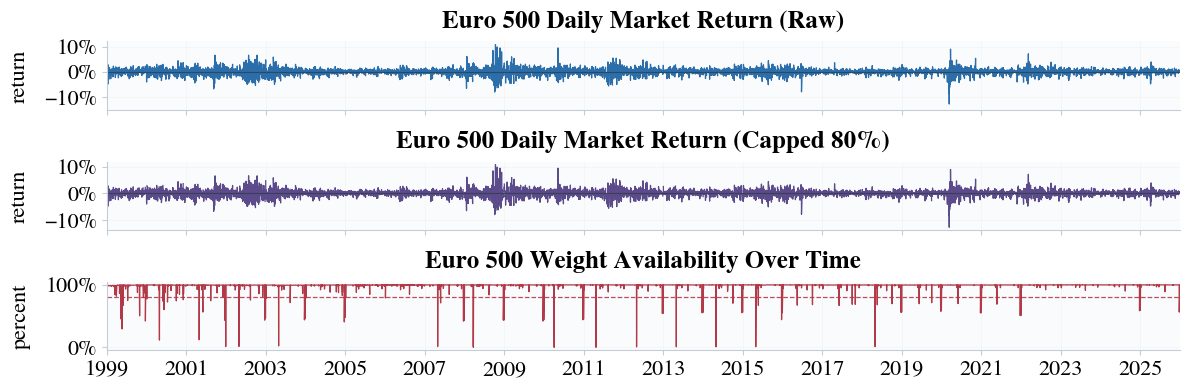

Saved Step 3.1 plot: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/Euro500_IndexReturns/euro500_step3_1_daily_diagnostics.png


In [9]:
NB_GRAPH_DIR = GRAPH_DIR / "Euro500_IndexReturns"
NB_GRAPH_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR = NB_GRAPH_DIR

diag_step3 = market_daily_out.copy()
diag_step3["date"] = pd.to_datetime(diag_step3["date"], errors="coerce")
diag_step3 = diag_step3.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
diag_step3["r_m"] = pd.to_numeric(diag_step3.get("r_m", diag_step3.get("market_return_ffmcap_capped80")), errors="coerce")

X_MIN_STEP3 = pd.Timestamp("1999-01-01")
X_MAX_STEP3 = pd.Timestamp("2025-12-31")
X_TICKS_STEP3 = pd.date_range("2000-01-01", "2026-01-01", freq="2YS")

diagnostics_daily = {
    "obs_days": int(len(diag_step3)),
    "start": pd.to_datetime(diag_step3["date"].min(), errors="coerce"),
    "end": pd.to_datetime(diag_step3["date"].max(), errors="coerce"),
    "mean_daily_return": float(diag_step3["market_return_ffmcap"].mean()),
    "vol_daily_return": float(diag_step3["market_return_ffmcap"].std()),
    "mean_daily_return_capped80": float(diag_step3["market_return_ffmcap_capped80"].mean()),
    "vol_daily_return_capped80": float(diag_step3["market_return_ffmcap_capped80"].std()),
    "mean_weight_available": float(pd.to_numeric(diag_step3["weight_available"], errors="coerce").mean()),
}

print("Step 3.1 - Daily diagnostics:")
print(f"  obs_days: {diagnostics_daily['obs_days']}")
print(f"  start: {diagnostics_daily['start'].strftime('%Y-%m-%d')}")
print(f"  end: {diagnostics_daily['end'].strftime('%Y-%m-%d')}")
print(f"  mean_daily_return: {diagnostics_daily['mean_daily_return']*100:.2f}%")
print(f"  vol_daily_return: {diagnostics_daily['vol_daily_return']*100:.2f}%")
print(f"  mean_daily_return_capped80: {diagnostics_daily['mean_daily_return_capped80']*100:.2f}%")
print(f"  vol_daily_return_capped80: {diagnostics_daily['vol_daily_return_capped80']*100:.2f}%")
print(f"  mean_weight_available: {diagnostics_daily['mean_weight_available']*100:.2f}%")

fig, axes = plt.subplots(3, 1, figsize=(12, 4), sharex=True)

axes[0].plot(diag_step3["date"], diag_step3["market_return_ffmcap"], lw=0.9, color=COLORS["blue"])
axes[0].axhline(0.0, color=COLORS["reference"], lw=0.8, alpha=0.7)
axes[0].set_title("Euro 500 Daily Market Return (Raw)")
axes[0].set_ylabel("return")
axes[0].set_ylim(top=0.12)

axes[1].plot(diag_step3["date"], diag_step3["market_return_ffmcap_capped80"], lw=0.9, color=COLORS["purple"])
axes[1].axhline(0.0, color=COLORS["reference"], lw=0.8, alpha=0.7)
axes[1].set_title("Euro 500 Daily Market Return (Capped 80%)")
axes[1].set_ylabel("return")

axes[2].plot(diag_step3["date"], pd.to_numeric(diag_step3["weight_available"], errors="coerce"), color=COLORS["accent"], lw=0.9)
axes[2].axhline(0.80, color=COLORS["accent"], lw=0.9, linestyle="--", alpha=0.9)
axes[2].set_title("Euro 500 Weight Availability Over Time")
axes[2].set_ylabel("percent")

axes[0].yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
axes[1].yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
axes[2].yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

for ax in axes:
    style_axes(ax, grid_axis="both")
    style_time_axis(ax, x_min=X_MIN_STEP3, x_max=X_MAX_STEP3, x_ticks=X_TICKS_STEP3, date_fmt="%Y")

step31_plot_path = TABLES_DIR / "euro500_step3_1_daily_diagnostics.png"
plt.tight_layout()
save_figure(plt.gcf(), step31_plot_path, dpi=300)
plt.show()
print(f"Saved Step 3.1 plot: {step31_plot_path}")

### 3.2 Monthly and Annual Compounded `r_m`

Monats- und Jahresrenditen aus `market_daily_out` (bereits in Sektion 2 erzeugt).



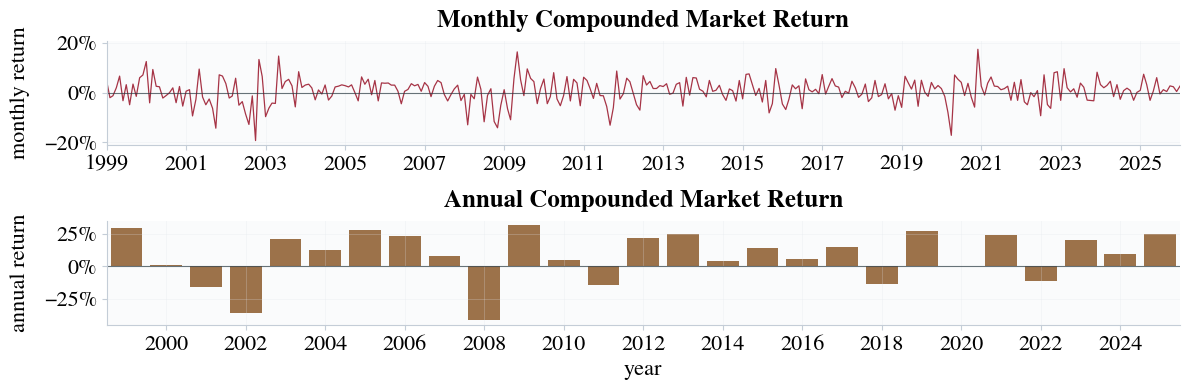

Saved Step 3.2 plot: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/Euro500_IndexReturns/euro500_step3_2_monthly_annual_rm.png


In [10]:
rm_df = market_daily_out.copy()
rm_df["date"] = pd.to_datetime(rm_df["date"], errors="coerce")
rm_df = rm_df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

# Monthly series (deduplicated by month_end)
if "r_m_compound_monthly" not in rm_df.columns:
    rm_df["r_m"] = pd.to_numeric(rm_df.get("r_m", rm_df.get("market_return_ffmcap_capped80")), errors="coerce")
    rm_df["month_end"] = rm_df["date"].dt.to_period("M").dt.to_timestamp("M")
    rm_month = (
        rm_df.loc[rm_df["r_m"].notna(), ["month_end", "r_m"]]
        .groupby("month_end", as_index=False)
        .agg(r_m_compound_monthly=("r_m", lambda s: float((1.0 + s).prod() - 1.0)))
    )
else:
    rm_df["month_end"] = rm_df["date"].dt.to_period("M").dt.to_timestamp("M")
    rm_month = rm_df[["month_end", "r_m_compound_monthly"]].dropna().drop_duplicates("month_end")

# Annual series (deduplicated by year)
if "r_m_compound_annual" not in rm_df.columns:
    rm_df["r_m"] = pd.to_numeric(rm_df.get("r_m", rm_df.get("market_return_ffmcap_capped80")), errors="coerce")
    rm_df["year"] = rm_df["date"].dt.year
    rm_year = (
        rm_df.loc[rm_df["r_m"].notna(), ["year", "r_m"]]
        .groupby("year", as_index=False)
        .agg(r_m_compound_annual=("r_m", lambda s: float((1.0 + s).prod() - 1.0)))
    )
else:
    rm_df["year"] = rm_df["date"].dt.year
    rm_year = rm_df[["year", "r_m_compound_annual"]].dropna().drop_duplicates("year")

fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=False)

axes[0].plot(rm_month["month_end"], rm_month.iloc[:, 1], color=COLORS["red"], lw=0.9)
axes[0].axhline(0.0, color=COLORS["reference"], lw=0.8, alpha=0.7)
axes[0].set_title("Monthly Compounded Market Return")
axes[0].set_ylabel("monthly return")
axes[0].yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
style_axes(axes[0], grid_axis="both")
style_time_axis(axes[0], x_min=pd.Timestamp("1999-01-01"), x_max=pd.Timestamp("2025-12-31"), x_ticks=pd.date_range("2000-01-01", "2026-01-01", freq="2YS"), date_fmt="%Y")

rm_year_plot = rm_year[rm_year["year"].astype(int) >= 1999].copy()
axes[1].bar(rm_year_plot["year"].astype(int), rm_year_plot.iloc[:, 1], color=COLORS["brown"], alpha=0.85, width=0.8)
axes[1].axhline(0.0, color=COLORS["reference"], lw=0.8, alpha=0.7)
axes[1].set_title("Annual Compounded Market Return")
axes[1].set_ylabel("annual return")
axes[1].set_xlabel("year")
axes[1].yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
style_axes(axes[1], grid_axis="both")
annual_tick_years = list(range(2000, int(rm_year_plot["year"].max()) + 1, 2)) if not rm_year_plot.empty else []
axes[1].set_xticks(annual_tick_years)
if not rm_year_plot.empty:
    axes[1].set_xlim(1998.5, int(rm_year_plot["year"].max()) + 0.5)


step32_plot_path = TABLES_DIR / "euro500_step3_2_monthly_annual_rm.png"
plt.tight_layout()
save_figure(plt.gcf(), step32_plot_path, dpi=300)
plt.show()
print(f"Saved Step 3.2 plot: {step32_plot_path}")



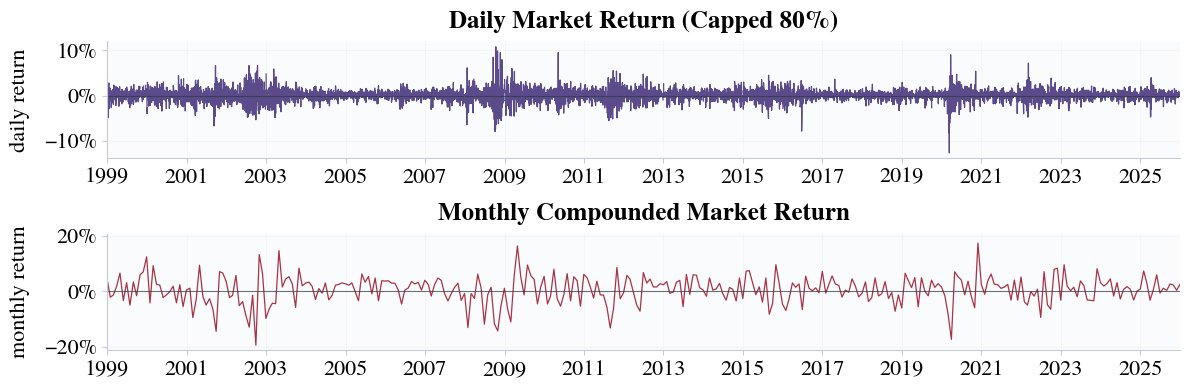

Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/Euro500_IndexReturns/euro500_step3_2_daily_monthly_rm.png


In [11]:
# --- Daily + Monthly combined plot ---
dm_df = market_daily_out.copy()
dm_df["date"] = pd.to_datetime(dm_df["date"], errors="coerce")
dm_df = dm_df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
dm_df["r_m"] = pd.to_numeric(dm_df.get("r_m", dm_df.get("market_return_ffmcap_capped80")), errors="coerce")

# Monthly series
dm_df["month_end"] = dm_df["date"].dt.to_period("M").dt.to_timestamp("M")
if "r_m_compound_monthly" not in dm_df.columns:
    dm_month = (
        dm_df.loc[dm_df["r_m"].notna(), ["month_end", "r_m"]]
        .groupby("month_end", as_index=False)
        .agg(r_m_compound_monthly=("r_m", lambda s: float((1.0 + s).prod() - 1.0)))
    )
else:
    dm_month = dm_df[["month_end", "r_m_compound_monthly"]].dropna().drop_duplicates("month_end")

fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=False)

# Top: Daily Market Return (Capped 80%)
axes[0].plot(dm_df["date"], dm_df["market_return_ffmcap_capped80"], lw=0.9, color=COLORS["purple"])
axes[0].axhline(0.0, color=COLORS["reference"], lw=0.8, alpha=0.7)
axes[0].set_title("Daily Market Return (Capped 80%)")
axes[0].set_ylabel("daily return")
axes[0].yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
style_axes(axes[0], grid_axis="both")
style_time_axis(axes[0], x_min=pd.Timestamp("1999-01-01"), x_max=pd.Timestamp("2025-12-31"), x_ticks=pd.date_range("2000-01-01", "2026-01-01", freq="2YS"), date_fmt="%Y")

# Bottom: Monthly Compounded Market Return
axes[1].plot(dm_month["month_end"], dm_month.iloc[:, 1], color=COLORS["red"], lw=0.9)
axes[1].axhline(0.0, color=COLORS["reference"], lw=0.8, alpha=0.7)
axes[1].set_title("Monthly Compounded Market Return")
axes[1].set_ylabel("monthly return")
axes[1].yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
style_axes(axes[1], grid_axis="both")
style_time_axis(axes[1], x_min=pd.Timestamp("1999-01-01"), x_max=pd.Timestamp("2025-12-31"), x_ticks=pd.date_range("2000-01-01", "2026-01-01", freq="2YS"), date_fmt="%Y")

step32_dm_path = TABLES_DIR / "euro500_step3_2_daily_monthly_rm.png"
plt.tight_layout()
save_figure(plt.gcf(), step32_dm_path, dpi=300)
plt.show()
print(f"Saved: {step32_dm_path}")

### 3.3 Risk-Free Rate Plots

Daily und annualisierte €STR-Reihe (aus `market_daily_out`).



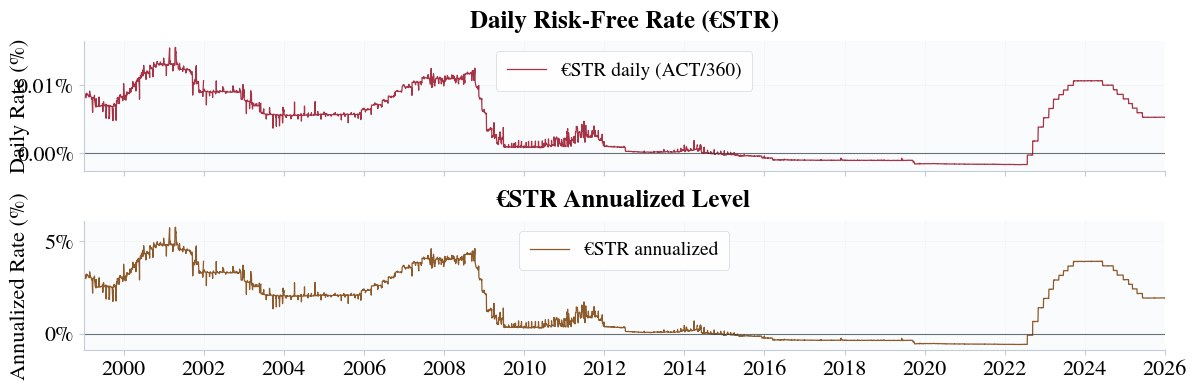

Saved RF plot: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/Euro500_IndexReturns/euro500_rf_daily_and_annual.png


In [12]:
rf_plot = market_daily_out.copy()
rf_plot["date"] = pd.to_datetime(rf_plot["date"], errors="coerce")
rf_plot = rf_plot.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

if "rf_daily" in rf_plot.columns and rf_plot["rf_daily"].notna().any():
    fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)

    ax = axes[0]
    ax.plot(rf_plot["date"], rf_plot["rf_daily"], lw=0.9, color=COLORS["red"], label="€STR daily (ACT/360)")
    ax.axhline(0.0, color=COLORS["reference"], lw=0.8, alpha=0.7)
    ax.set_title("Daily Risk-Free Rate (€STR)")
    ax.set_ylabel("Daily Rate (%)")
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=2))
    style_axes(ax, grid_axis="both")
    style_legend(ax, loc="best", frameon=True)

    ax = axes[1]
    if "rf_estr_annual" in rf_plot.columns and rf_plot["rf_estr_annual"].notna().any():
        ax.plot(rf_plot["date"], rf_plot["rf_estr_annual"], lw=0.9, color=COLORS["brown"], label="€STR annualized")
    ax.axhline(0.0, color=COLORS["reference"], lw=0.8, alpha=0.7)
    ax.set_title("€STR Annualized Level")
    ax.set_ylabel("Annualized Rate (%)")
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    style_axes(ax, grid_axis="both")
    style_legend(ax, loc="best", frameon=True)

    for ax in axes:
        ax.yaxis.set_label_coords(-0.05, 0.5)
        ax.yaxis.labelpad = 5
        ax.set_xlim(pd.Timestamp("1999-01-01"), pd.Timestamp("2025-12-31"))
        ax.set_xticks(pd.date_range("2000-01-01", "2026-01-01", freq="2YS"))
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    rf_png_path = TABLES_DIR / "euro500_rf_daily_and_annual.png"
    plt.tight_layout()
    save_figure(plt.gcf(), rf_png_path, dpi=300)
    plt.show()
    print(f"Saved RF plot: {rf_png_path}")
else:
    print("No rf_daily series available in market_daily_out.")



## 4. Benchmark Comparison

Diese Sektion bündelt Benchmark-Pulls und relative Performance-Auswertungen.



### 4.1 Benchmark Pull and Comparison (LSEG)



In [13]:
def pull_index_daily_return(ric: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    """
    Pull daily benchmark returns from LSEG and choose the best available field:
    earliest valid start date, then highest number of observations.
    """
    start = pd.to_datetime(start, errors="coerce")
    end = pd.to_datetime(end, errors="coerce")
    if pd.isna(start) or pd.isna(end):
        raise ValueError(f"Invalid benchmark date bounds for {ric}: start={start}, end={end}")

    start_str = start.strftime("%Y-%m-%d")
    end_str = end.strftime("%Y-%m-%d")

    tr_fields = [
        "TR.IndexNetReturn",
        "TR.TotalReturn",
        "TR.IndexTotalReturn",
        "TR.IndexGrossReturn",
    ]
    if str(ric).strip().upper() == ".STOXXR":
        # Workspace/API diagnostics showed TRDPRC_1 has the long history (1998+).
        price_fields = ["TRDPRC_1"]
    else:
        price_fields = [
            "CLOSE",
            "TR.PriceClose",
            "TRDPRC_1",
        ]

    last_err = None
    tried = []

    def _coerce_num(s: pd.Series) -> pd.Series:
        t = s.astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False).str.strip()
        t = t.replace({"": np.nan, "None": np.nan, "nan": np.nan})
        return pd.to_numeric(t, errors="coerce")

    candidates: list[tuple[pd.Timestamp, int, pd.DataFrame]] = []

    # Try TR-like return fields first (native return if available).
    for field in tr_fields:
        tried.append(field)
        try:
            raw = ld.get_history(
                universe=[ric],
                fields=[field],
                start=start_str,
                end=end_str,
                interval="daily",
            )
            if raw is None or len(raw) == 0:
                continue

            x = raw.copy().reset_index()
            if x.empty:
                continue

            date_col = x.columns[0]
            value_candidates = [c for c in x.columns if c != date_col]
            if not value_candidates:
                continue

            best_col = None
            best_non_na = -1
            for c in value_candidates:
                non_na = int(_coerce_num(x[c]).notna().sum())
                if non_na > best_non_na:
                    best_non_na = non_na
                    best_col = c
            if best_col is None or best_non_na <= 0:
                continue

            out = pd.DataFrame({
                "date": pd.to_datetime(x[date_col], errors="coerce"),
                "value": _coerce_num(x[best_col]),
            }).dropna(subset=["date", "value"]).sort_values("date")
            if out.empty:
                continue

            max_abs = out["value"].abs().quantile(0.99)
            out["ret"] = out["value"] / 100.0 if max_abs > 1.5 else out["value"]
            out = out.dropna(subset=["ret"]).copy()
            if out.empty:
                continue

            out["ric"] = ric
            out["field_used"] = field
            out["is_total_return"] = True
            cmin = pd.to_datetime(out["date"], errors="coerce").min()
            nobs = int(out["ret"].notna().sum())
            candidates.append((cmin, -nobs, out[["date", "ric", "field_used", "is_total_return", "ret"]]))
            print(f"    field {field}: n={nobs} {cmin.date()}..{pd.to_datetime(out["date"]).max().date()}")

        except Exception as e:
            last_err = e
            continue

    # Fallback: derive returns from index levels.
    for field in price_fields:
        tried.append(field)
        try:
            raw = ld.get_history(
                universe=[ric],
                fields=[field],
                start=start_str,
                end=end_str,
                interval="daily",
            )
            if raw is None or len(raw) == 0:
                continue

            x = raw.copy().reset_index()
            if x.empty:
                continue

            date_col = x.columns[0]
            value_candidates = [c for c in x.columns if c != date_col]
            if not value_candidates:
                continue

            best_col = None
            best_non_na = -1
            for c in value_candidates:
                non_na = int(_coerce_num(x[c]).notna().sum())
                if non_na > best_non_na:
                    best_non_na = non_na
                    best_col = c
            if best_col is None or best_non_na <= 1:
                continue

            out = pd.DataFrame({
                "date": pd.to_datetime(x[date_col], errors="coerce"),
                "value": _coerce_num(x[best_col]),
            }).dropna(subset=["date", "value"]).sort_values("date")
            if len(out) <= 1:
                continue

            out["ret"] = out["value"].pct_change()
            out = out.dropna(subset=["ret"]).copy()
            if out.empty:
                continue

            out["ric"] = ric
            out["field_used"] = f"{field}->pct_change"
            out["is_total_return"] = True
            cmin = pd.to_datetime(out["date"], errors="coerce").min()
            nobs = int(out["ret"].notna().sum())
            candidates.append((cmin, -nobs, out[["date", "ric", "field_used", "is_total_return", "ret"]]))
            print(f"    field {field}: n={nobs} {cmin.date()}..{pd.to_datetime(out["date"]).max().date()}")

        except Exception as e:
            last_err = e
            continue

    if candidates:
        candidates.sort(key=lambda x: (x[0], x[1]))
        return candidates[0][2].sort_values("date").reset_index(drop=True)

    msg = f"No usable TR benchmark series for {ric}. Tried fields: {tried}"
    if last_err is not None:
        msg += f" | last error: {type(last_err).__name__}: {last_err}"
    raise ValueError(msg)


# File cache for benchmark pulls to avoid repeated LSEG requests.
BENCH_CACHE_DIR = CACHE_DATA_DIR / "benchmark_cache"
BENCH_CACHE_DIR.mkdir(parents=True, exist_ok=True)
BENCH_CACHE_SCHEMA_VERSION = "v5"


def _bench_cache_path(series_name: str, start: pd.Timestamp, end: pd.Timestamp) -> Path:
    key = str(series_name).replace(".", "_dot_").replace("/", "_")
    s = pd.to_datetime(start).strftime("%Y%m%d")
    e = pd.to_datetime(end).strftime("%Y%m%d")
    return BENCH_CACHE_DIR / f"bench_{BENCH_CACHE_SCHEMA_VERSION}_{key}_{s}_{e}.parquet"


def _pull_benchmark_best_lseg(series_name: str, ric_candidates: list[str], start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    cache_path = _bench_cache_path(series_name=series_name, start=start, end=end)
    if cache_path.exists():
        out = pd.read_parquet(cache_path)
        out["date"] = pd.to_datetime(out["date"], errors="coerce")
        out = out.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
        print(f"Cache hit: {series_name} -> {cache_path.name}")
        return out

    best = None
    tried_meta = []

    ld.open_session()
    try:
        for ric in ric_candidates:
            try:
                cur = pull_index_daily_return(ric=ric, start=start, end=end)
                if cur is None or cur.empty:
                    tried_meta.append((ric, "empty"))
                    continue

                cur = cur.dropna(subset=["date", "ret"]).sort_values("date").reset_index(drop=True)
                if cur.empty:
                    tried_meta.append((ric, "empty_after_clean"))
                    continue

                cmin = pd.to_datetime(cur["date"], errors="coerce").min()
                cmax = pd.to_datetime(cur["date"], errors="coerce").max()
                nobs = int(cur["ret"].notna().sum())
                tried_meta.append((ric, f"ok n={nobs} {cmin.date()}..{cmax.date()} field={cur['field_used'].iloc[0]}"))

                score = (cmin, -nobs)
                if (best is None) or (score < best[0]):
                    best = (score, cur)
            except Exception as e:
                tried_meta.append((ric, f"fail {type(e).__name__}: {e}"))
    finally:
        ld.close_session()

    print(f"LSEG candidates for {series_name}:")
    for ric, msg in tried_meta:
        print(f"  {ric}: {msg}")

    if best is None:
        raise ValueError(f"No usable LSEG benchmark series for {series_name}. Tried: {ric_candidates}")

    out = best[1].copy()
    out.to_parquet(cache_path, index=False)
    return out


def _resolve_benchmark_bounds(min_start: str = "1999-01-01") -> tuple[pd.Timestamp, pd.Timestamp]:
    candidates = []
    min_start_dt = pd.to_datetime(min_start).normalize()

    if "market_daily_out" in globals() and isinstance(market_daily_out, pd.DataFrame) and "date" in market_daily_out.columns:
        d = pd.to_datetime(market_daily_out["date"], errors="coerce")
        if d.notna().any():
            candidates.append((d.min(), d.max(), "market_daily_out"))

    if "returns_in_index" in globals() and isinstance(returns_in_index, pd.DataFrame) and "date" in returns_in_index.columns:
        d = pd.to_datetime(returns_in_index["date"], errors="coerce")
        if d.notna().any():
            candidates.append((d.min(), d.max(), "returns_in_index"))

    if not candidates:
        raise ValueError("Could not resolve benchmark date bounds (no valid dates in market_daily_out/returns_in_index).")

    start_dt, end_dt, src = candidates[0]
    start_dt = min(start_dt.normalize(), min_start_dt)
    print(f"Benchmark date bounds from {src} (forced min start {min_start_dt.date()}): {start_dt.date()} -> {end_dt.date()}")
    return start_dt, end_dt


start_dt, end_dt = _resolve_benchmark_bounds()

# Candidate universes: try return-index RICs first, then price-index RICs with pct_change fallback.
bench_specs = [
    {"series": "stoxx600_ret", "rics": [".STOXXR"]},
    {"series": "stoxx_euro50_ret", "rics": [".STOXX50ER"]},
]

bench_frames = []
bench_meta = []

for spec in bench_specs:
    b = _pull_benchmark_best_lseg(
        series_name=spec["series"],
        ric_candidates=spec["rics"],
        start=start_dt,
        end=end_dt,
    ).rename(columns={"ret": spec["series"]})

    if b.empty:
        raise ValueError(f"Benchmark pull returned empty frame for {spec['series']}")

    bench_meta.append(
        b[["ric", "field_used", "is_total_return"]]
        .drop_duplicates()
        .assign(series=spec["series"])
    )
    bench_frames.append(b[["date", spec["series"]]])

bench_info = pd.concat(bench_meta, ignore_index=True)
print("Benchmark fields used:")
display(bench_info)

cmp_cols = [
    "date",
    "quarter",
    "market_return_ffmcap",
    "market_return_ffmcap_capped80",
    "weight_available",
]
for c in ["rf_daily", "rf_estr_annual", "excess_market_return_ffmcap", "excess_market_return_ffmcap_capped80"]:
    if c in market_daily_out.columns:
        cmp_cols.append(c)
cmp_df = market_daily_out[cmp_cols].copy()
for bf in bench_frames:
    cmp_df = cmp_df.merge(bf, on="date", how="left")

print("Comparison frame date range:", cmp_df["date"].min(), "to", cmp_df["date"].max())
print("Missing benchmark shares:")
for c in ["stoxx600_ret", "stoxx_euro50_ret"]:
    print(f"  {c}: {cmp_df[c].isna().mean():.2%}")

display(cmp_df.head())
display(cmp_df.tail())

Benchmark date bounds from market_daily_out (forced min start 1999-01-01): 1998-01-02 -> 2025-12-31
Cache hit: stoxx600_ret -> bench_v5_stoxx600_ret_19980102_20251231.parquet
Cache hit: stoxx_euro50_ret -> bench_v5_stoxx_euro50_ret_19980102_20251231.parquet
Benchmark fields used:


,ric,field_used,is_total_return,series
0,.STOXXR,TRDPRC_1->pct_change,True,stoxx600_ret
1,.STOXX50ER,TRDPRC_1->pct_change,True,stoxx_euro50_ret


Comparison frame date range: 1998-01-02 00:00:00 to 2025-12-31 00:00:00
Missing benchmark shares:
  stoxx600_ret: 0.43%
  stoxx_euro50_ret: 0.40%


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,rf_daily,rf_estr_annual,excess_market_return_ffmcap,excess_market_return_ffmcap_capped80,stoxx600_ret,stoxx_euro50_ret
0,1998-01-02,1998Q1,0.027136,0.027136,0.970659,0.000088,0.032,0.027049,0.027049,NaN,NaN
1,1998-01-05,1998Q1,0.019075,0.019075,0.963920,0.000088,0.032,0.018987,0.018987,0.018551,NaN
2,1998-01-06,1998Q1,-0.005882,NaN,0.694501,0.000088,0.032,-0.005970,NaN,-0.003582,-0.009840
3,1998-01-07,1998Q1,-0.004753,-0.004753,0.970225,0.000088,0.032,-0.004840,-0.004840,-0.002272,-0.000961
4,1998-01-08,1998Q1,-0.011034,-0.011034,0.971244,0.000088,0.032,-0.011122,-0.011122,-0.010061,-0.010098


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,rf_daily,rf_estr_annual,excess_market_return_ffmcap,excess_market_return_ffmcap_capped80,stoxx600_ret,stoxx_euro50_ret
7179,2025-12-23,2025Q4,0.000231,0.000231,0.999157,0.000053,0.01925,0.000178,0.000178,0.003400,0.000975
7180,2025-12-24,2025Q4,-0.000686,NaN,0.565076,0.000053,0.01926,-0.000739,NaN,-0.000054,-0.000529
7181,2025-12-29,2025Q4,0.001517,0.001517,0.999602,0.000053,0.01934,0.001464,0.001464,0.001073,0.000951
7182,2025-12-30,2025Q4,0.007107,0.007107,0.999587,0.000053,0.01930,0.007054,0.007054,0.005983,0.007739
7183,2025-12-31,2025Q4,-0.000924,NaN,0.573872,0.000053,0.01921,-0.000977,NaN,-0.000870,-0.000496


### 4.2 Relative Performance Views



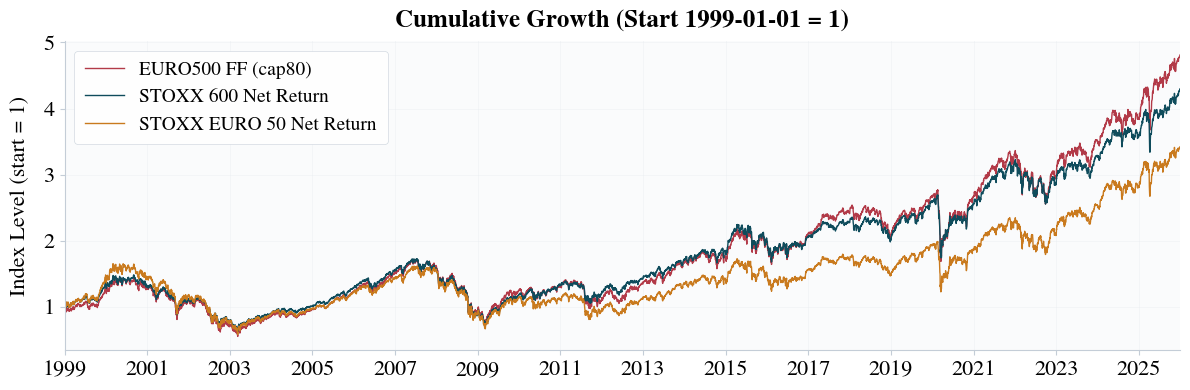

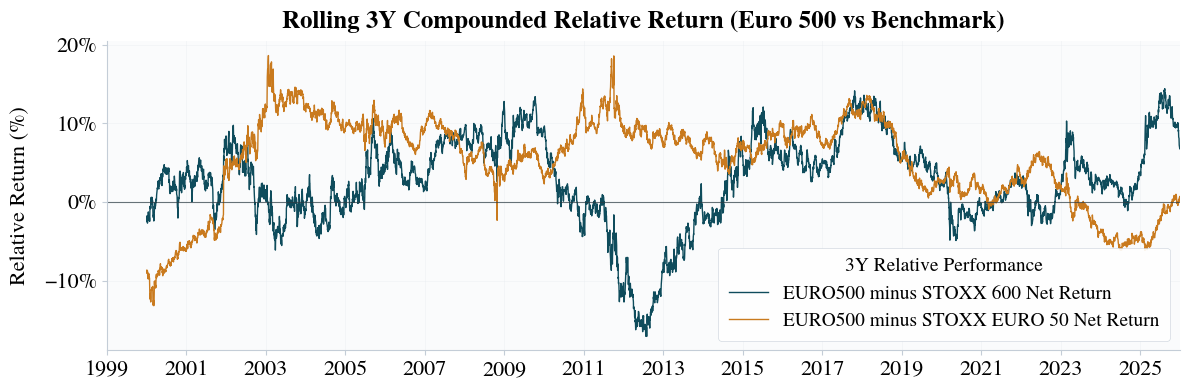

In [14]:

def _normalized_cum_level(ret: pd.Series, base: float = 1.0) -> pd.Series:
    """Convert daily returns into a normalized cumulative level."""
    r = pd.to_numeric(ret, errors="coerce")
    out = (1.0 + r.fillna(0.0)).cumprod() * float(base)
    return out

NB_GRAPH_DIR = GRAPH_DIR / "Euro500_IndexReturns"
NB_GRAPH_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR = NB_GRAPH_DIR

cmp_plot = cmp_df.copy()
cmp_plot["date"] = pd.to_datetime(cmp_plot["date"], errors="coerce")
cmp_plot = cmp_plot.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

START_NORM = pd.Timestamp("1999-01-01")
cmp_norm = cmp_plot[cmp_plot["date"] >= START_NORM].copy()

series_cols = [
    "market_return_ffmcap_capped80",
    "stoxx600_ret",
    "stoxx_euro50_ret",
]
series_cols = [c for c in series_cols if c in cmp_norm.columns]

for c in series_cols:
    cmp_norm[f"lvl_{c}"] = _normalized_cum_level(cmp_norm[c])

# 3Y (756 trading days) rolling relative performance vs benchmarks
rolling_win = 756
ROLL_START = pd.Timestamp("1999-01-01")
X_MIN = pd.Timestamp("1999-01-01")
X_MAX = pd.Timestamp("2025-12-31")
X_TICKS = pd.date_range("2000-01-01", "2026-01-01", freq="2YS")
rel = cmp_plot.loc[cmp_plot["date"] >= ROLL_START, ["date", "market_return_ffmcap_capped80"]].copy()
if "stoxx600_ret" in cmp_plot.columns:
    rel["spread_vs_stoxx600"] = cmp_plot["market_return_ffmcap_capped80"] - cmp_plot["stoxx600_ret"]
if "stoxx_euro50_ret" in cmp_plot.columns:
    rel["spread_vs_euro50"] = cmp_plot["market_return_ffmcap_capped80"] - cmp_plot["stoxx_euro50_ret"]

roll = rel[["date"]].copy()
bench_col_map = {
    "spread_vs_stoxx600": "stoxx600_ret",
    "spread_vs_euro50": "stoxx_euro50_ret",
}

for c in [x for x in rel.columns if x.startswith("spread_")]:
    bench_col = bench_col_map.get(c)
    if not bench_col or bench_col not in cmp_plot.columns:
        continue

    bench_series = pd.to_numeric(cmp_plot.loc[cmp_plot["date"] >= ROLL_START, bench_col], errors="coerce")
    euro_series = pd.to_numeric(rel["market_return_ffmcap_capped80"], errors="coerce")

    rel_daily = (1.0 + euro_series) / (1.0 + bench_series) - 1.0
    rel_valid = euro_series.notna() & bench_series.notna()

    rel_growth = (1.0 + rel_daily.fillna(0.0)).rolling(rolling_win, min_periods=252).apply(np.prod, raw=True) - 1.0
    rel_growth[rel_valid.rolling(rolling_win, min_periods=1).sum() < 252] = np.nan
    roll[f"roll3y_{c}"] = rel_growth

# Plot 1: cumulative growth
fig1, ax = plt.subplots(figsize=(12, 4))
if "lvl_market_return_ffmcap_capped80" in cmp_norm.columns:
    ax.plot(cmp_norm["date"], cmp_norm["lvl_market_return_ffmcap_capped80"], color=COLORS["accent"], label="EURO500 FF (cap80)")
if "lvl_stoxx600_ret" in cmp_norm.columns:
    ax.plot(cmp_norm["date"], cmp_norm["lvl_stoxx600_ret"], color=COLORS["primary"], label="STOXX 600 Net Return")
if "lvl_stoxx_euro50_ret" in cmp_norm.columns:
    ax.plot(cmp_norm["date"], cmp_norm["lvl_stoxx_euro50_ret"], color=COLORS["orange"], label="STOXX EURO 50 Net Return")
ax.set_title("Cumulative Growth (Start 1999-01-01 = 1)")
ax.set_ylabel("Index Level (start = 1)")
style_axes(ax, grid_axis="both")
style_legend(ax, loc="best", frameon=True)
style_time_axis(ax, x_min=X_MIN, x_max=X_MAX, x_ticks=X_TICKS, date_fmt="%Y")

cum_growth_plot_path = TABLES_DIR / "euro500_cum_growth.png"
plt.tight_layout()
save_figure(fig1, cum_growth_plot_path, dpi=300)
plt.show()

# Plot 2: rolling 3Y relative performance
fig2, ax = plt.subplots(figsize=(12, 4))
roll_label_map = {
    "roll3y_spread_vs_stoxx600": "EURO500 minus STOXX 600 Net Return",
    "roll3y_spread_vs_euro50": "EURO500 minus STOXX EURO 50 Net Return",
}
for c in [x for x in roll.columns if x.startswith("roll3y_")]:
    ax.plot(roll["date"], roll[c], color=(COLORS["primary"] if "stoxx600" in c else COLORS["orange"]), label=roll_label_map.get(c, c.replace("roll3y_", "")))
ax.axhline(0.0, color=COLORS["reference"], lw=0.8, alpha=0.7)
ax.set_title("Rolling 3Y Compounded Relative Return (Euro 500 vs Benchmark)")
ax.set_ylabel("Relative Return (%)")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
style_axes(ax, grid_axis="both")
style_legend(ax, title="3Y Relative Performance", loc="lower right", frameon=True)
style_time_axis(ax, x_min=X_MIN, x_max=X_MAX, x_ticks=X_TICKS, date_fmt="%Y")

roll3y_plot_path = TABLES_DIR / "euro500_roll3y.png"
plt.tight_layout()
save_figure(fig2, roll3y_plot_path, dpi=300)
plt.show()


# Yearly return spread table
annual = cmp_plot.copy()
annual["year"] = annual["date"].dt.year
ann_rows = []
for y, g in annual.groupby("year"):
    row = {"year": int(y)}
    if g["market_return_ffmcap_capped80"].notna().any():
        row["euro500_ann"] = float((1 + g["market_return_ffmcap_capped80"].fillna(0)).prod() - 1)
    if "stoxx600_ret" in g.columns and g["stoxx600_ret"].notna().any():
        row["stoxx600_ann"] = float((1 + g["stoxx600_ret"].fillna(0)).prod() - 1)
        row["spread_vs_stoxx600"] = row.get("euro500_ann", np.nan) - row["stoxx600_ann"]
    if "stoxx_euro50_ret" in g.columns and g["stoxx_euro50_ret"].notna().any():
        row["stoxx_euro50_ann"] = float((1 + g["stoxx_euro50_ret"].fillna(0)).prod() - 1)
        row["spread_vs_euro50"] = row.get("euro500_ann", np.nan) - row["stoxx_euro50_ann"]
    ann_rows.append(row)

annual_spread = pd.DataFrame(ann_rows).sort_values("year").reset_index(drop=True)

## 5. Monthly Rolling CAPM Beta (Lagged)

**Ziel**
- Schätzung eines stabileren, firmenspezifischen CAPM-Betas auf Monatsbasis.
- Keine Daily-Beta-Schätzung mehr; Beta wird aus monatlich compounding-basierten Returns berechnet.

**Methode**
- Monthly compounded Stock-Return und Market-Return.
- Rolling OLS-Slope je Firma (Standard: 36 Monate, min. 24 Beobachtungen):
  - `beta = cov(stock, market) / var(market)`
- Für einen Tag in Monat `M` wird das Beta von Monatsende `M-1` verwendet (lag1, no look-ahead).

**Input**
- `Project_Data/intermediate/daily_returns_company_all.parquet`
- `Project_Data/intermediate/euro500_daily_returns.parquet`
- In-Memory/Parquet Marktserie (`market_return_ffmcap_capped80`)

**Output (bearbeitet)**
- `Project_Data/intermediate/daily_returns_company_all.parquet` (inkl. `beta`)
- `Project_Data/intermediate/euro500_daily_returns.parquet` (inkl. gemergtem `beta`)
- `Project_Data/intermediate/euro500.parquet` (beta per `firm_id` + `date`)



### 5A. Methodik und QC-Regeln der Beta-Schätzung (Monthly)
**Formel**
$$
\beta_{i,m}=\frac{\operatorname{Cov}_W(r_{i,m},r_{m,m})}{\operatorname{Var}_W(r_{m,m})}
$$
**Definitionen**
- `r_{i,m}`: monatliche Firmenrendite (aus daily compounding)
- `r_{m,m}`: monatliche Marktrendite (aus daily compounding)
- `W`: rollendes Fenster in Monaten (`BETA_WINDOW_MONTHS`)
**Lag-Regel (No Look-Ahead)**
- Für Tagesbeobachtungen im Monat `M` wird `beta` aus Schätzung bis Monatsende `M-1` verwendet.
**Risk-free Handling**
- Falls tägliche `rf_daily`-Serie in der Marktquelle vorhanden ist: Beta auf Excess-Monthly-Returns.
- Sonst: Beta auf Raw-Monthly-Returns.
**QC-Regeln**
- Mindestbeobachtungen pro Rollfenster: `BETA_MIN_OBS = 12`
- Marktvarianz im Fenster > `MIN_VAR_M_ROLL`
- Outlier-Cap: `|beta| <= MAX_ABS_BETA`


In [15]:
MARKET_COL = "market_return_ffmcap_capped80"
BETA_WINDOW_MONTHS = 36
BETA_MIN_OBS = 12
MIN_VAR_M_ROLL = 1e-10
MAX_ABS_BETA = 10.0
RETURNS_ALL_PATH = DATA_DIR / "daily_returns_company_all.parquet"
OUTPUT_DAILY_RETURNS_EURO500 = globals().get("RETURNS_IN_INDEX_PATH", DATA_DIR / "euro500_daily_returns.parquet")
MARKET_RETURNS_PATH = DATA_DIR / "euro500_index_returns.parquet"
if "market_daily_out" in locals() and isinstance(market_daily_out, pd.DataFrame):
    market_src = market_daily_out.copy()
elif MARKET_RETURNS_PATH.exists():
    market_src = pd.read_parquet(MARKET_RETURNS_PATH).copy()
else:
    raise FileNotFoundError(f"No market series found. Run Step 2 first or provide file: {MARKET_RETURNS_PATH}")
if MARKET_COL not in market_src.columns:
    raise ValueError(f"Missing market column: {MARKET_COL}")
if not RETURNS_ALL_PATH.exists():
    raise FileNotFoundError(f"File not found: {RETURNS_ALL_PATH}")
def _clean_id(s: pd.Series) -> pd.Series:
    out = s.astype("string").str.strip()
    return out.where(out.notna() & out.ne(""), pd.NA)
def _build_firm_id(df: pd.DataFrame) -> pd.Series:
    out = pd.Series(pd.NA, index=df.index, dtype="string")
    if "ISIN" in df.columns:
        out = out.fillna("ISIN:" + _clean_id(df["ISIN"]))
    if "RIC_current" in df.columns:
        out = out.fillna("RIC:" + _clean_id(df["RIC_current"]))
    if "RIC" in df.columns:
        out = out.fillna("RIC:" + _clean_id(df["RIC"]))
    if "SEDOL" in df.columns:
        out = out.fillna("SEDOL:" + _clean_id(df["SEDOL"]))
    return out
def _compound_return(s: pd.Series) -> float:
    v = pd.to_numeric(s, errors="coerce")
    v = v[np.isfinite(v)]
    if len(v) == 0:
        return np.nan
    if ((1.0 + v) <= 0.0).any():
        return np.nan
    return float((1.0 + v).prod() - 1.0)
# ---------- load full daily panel ----------
returns_all = pd.read_parquet(RETURNS_ALL_PATH).copy()
returns_all_orig_cols = list(returns_all.columns)
all_raw = len(returns_all)
returns_all["date"] = pd.to_datetime(returns_all["date"], errors="coerce").dt.normalize()
returns_all["ret"] = pd.to_numeric(returns_all["ret"], errors="coerce")
if "firm_id" in returns_all.columns:
    returns_all["firm_id"] = _clean_id(returns_all["firm_id"]).fillna(_build_firm_id(returns_all))
else:
    returns_all["firm_id"] = _build_firm_id(returns_all)
returns_all = (
    returns_all
    .dropna(subset=["date", "firm_id"])
    .sort_values(["firm_id", "date"], kind="mergesort")
    .drop_duplicates(subset=["firm_id", "date"], keep="last")
    .reset_index(drop=True)
)
# ---------- market daily series ----------
market_daily = market_src[["date", MARKET_COL] + (["rf_daily"] if "rf_daily" in market_src.columns else [])].copy()
market_daily["date"] = pd.to_datetime(market_daily["date"], errors="coerce").dt.normalize()
market_daily["market_ret_cap80"] = pd.to_numeric(market_daily[MARKET_COL], errors="coerce")
if "rf_daily" in market_daily.columns:
    market_daily["rf_daily"] = pd.to_numeric(market_daily["rf_daily"], errors="coerce")
market_daily = market_daily.dropna(subset=["date"]).groupby("date", as_index=False).median(numeric_only=True)
# merge market daily into full panel (needed downstream, incl. abnormal returns)
for c in ["market_ret_cap80"]:
    if c in returns_all.columns:
        returns_all = returns_all.drop(columns=[c])
returns_all = returns_all.merge(market_daily[["date", "market_ret_cap80"]], on="date", how="left", validate="m:1")
# ---------- monthly compounded returns ----------
stock_monthly = (
    returns_all[["firm_id", "date", "ret"]]
    .assign(month_end=lambda d: d["date"].dt.to_period("M").dt.to_timestamp("M"))
    .groupby(["firm_id", "month_end"], as_index=False)
    .agg(
        stock_ret_monthly=("ret", _compound_return),
        n_daily_stock=("ret", lambda s: int(pd.to_numeric(s, errors="coerce").notna().sum())),
    )
)
if "r_m_compound_monthly" in market_daily_out.columns:
    market_monthly = (
        market_daily_out[["date", "r_m_compound_monthly"]]
        .assign(month_end=lambda d: pd.to_datetime(d["date"], errors="coerce").dt.to_period("M").dt.to_timestamp("M"))
        .dropna(subset=["month_end", "r_m_compound_monthly"])
        .drop_duplicates("month_end")
        .rename(columns={"r_m_compound_monthly": "market_ret_monthly"})
    )
    market_monthly["n_daily_market"] = np.nan
else:
    market_monthly = (
        market_daily[["date", "market_ret_cap80"]]
        .assign(month_end=lambda d: d["date"].dt.to_period("M").dt.to_timestamp("M"))
        .groupby("month_end", as_index=False)
        .agg(
            market_ret_monthly=("market_ret_cap80", _compound_return),
            n_daily_market=("market_ret_cap80", lambda s: int(pd.to_numeric(s, errors="coerce").notna().sum())),
        )
    )
use_excess = False
if "rf_daily" in market_daily.columns and market_daily["rf_daily"].notna().any():
    rf_monthly = (
        market_daily[["date", "rf_daily"]]
        .assign(month_end=lambda d: d["date"].dt.to_period("M").dt.to_timestamp("M"))
        .groupby("month_end", as_index=False)
        .agg(rf_monthly=("rf_daily", _compound_return))
    )
    use_excess = True
else:
    rf_monthly = pd.DataFrame(columns=["month_end", "rf_monthly"])
beta_monthly_input = stock_monthly.merge(market_monthly[["month_end", "market_ret_monthly"]], on="month_end", how="left", validate="m:1")
if use_excess:
    beta_monthly_input = beta_monthly_input.merge(rf_monthly[["month_end", "rf_monthly"]], on="month_end", how="left", validate="m:1")
    beta_monthly_input["stock_beta_input"] = beta_monthly_input["stock_ret_monthly"] - beta_monthly_input["rf_monthly"]
    beta_monthly_input["market_beta_input"] = beta_monthly_input["market_ret_monthly"] - beta_monthly_input["rf_monthly"]
    beta_col_name = f"beta_monthly_excess_{BETA_WINDOW_MONTHS}m"
else:
    beta_monthly_input["stock_beta_input"] = beta_monthly_input["stock_ret_monthly"]
    beta_monthly_input["market_beta_input"] = beta_monthly_input["market_ret_monthly"]
    beta_col_name = f"beta_monthly_{BETA_WINDOW_MONTHS}m"
# ---------- rolling monthly beta per firm ----------
beta_monthly_input = beta_monthly_input.sort_values(["firm_id", "month_end"], kind="mergesort").reset_index(drop=True)
beta_monthly_input["_ok"] = beta_monthly_input[["stock_beta_input", "market_beta_input"]].notna().all(axis=1)
beta_monthly_input["_x"] = np.where(beta_monthly_input["_ok"], pd.to_numeric(beta_monthly_input["market_beta_input"], errors="coerce"), np.nan)
beta_monthly_input["_y"] = np.where(beta_monthly_input["_ok"], pd.to_numeric(beta_monthly_input["stock_beta_input"], errors="coerce"), np.nan)
beta_monthly_input["_xy"] = beta_monthly_input["_x"] * beta_monthly_input["_y"]
beta_monthly_input["_x2"] = beta_monthly_input["_x"] ** 2
gm = beta_monthly_input.groupby("firm_id", sort=False)
obs = gm["_ok"].rolling(BETA_WINDOW_MONTHS, min_periods=1).sum().reset_index(level=0, drop=True)
mean_x = gm["_x"].rolling(BETA_WINDOW_MONTHS, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_y = gm["_y"].rolling(BETA_WINDOW_MONTHS, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_xy = gm["_xy"].rolling(BETA_WINDOW_MONTHS, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_x2 = gm["_x2"].rolling(BETA_WINDOW_MONTHS, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
cov_xy = mean_xy - (mean_x * mean_y)
var_x = mean_x2 - (mean_x ** 2)
beta_est = np.where((obs >= BETA_MIN_OBS) & np.isfinite(var_x) & (var_x > MIN_VAR_M_ROLL), cov_xy / var_x, np.nan)
beta_est = np.where(np.abs(beta_est) <= MAX_ABS_BETA, beta_est, np.nan)
beta_monthly_input["beta_obs_window"] = pd.to_numeric(obs, errors="coerce")
beta_monthly_input["beta_var_market_window"] = pd.to_numeric(var_x, errors="coerce")
beta_monthly_input[beta_col_name] = pd.to_numeric(beta_est, errors="coerce")
# Store for Step 6B diagnostics
beta_monthly_est = beta_monthly_input[["firm_id", "month_end", beta_col_name, "beta_obs_window", "beta_var_market_window", "stock_ret_monthly", "market_ret_monthly"]].copy()
# ---------- lag1 monthly beta -> assign to daily rows ----------
beta_apply = beta_monthly_est[["firm_id", "month_end", beta_col_name]].drop_duplicates(["firm_id", "month_end"]).copy()
beta_apply["month_end_apply"] = pd.to_datetime(beta_apply["month_end"], errors="coerce") + pd.offsets.MonthEnd(1)
returns_all["month_end"] = returns_all["date"].dt.to_period("M").dt.to_timestamp("M")
returns_all = returns_all.merge(
    beta_apply[["firm_id", "month_end_apply", beta_col_name]],
    left_on=["firm_id", "month_end"],
    right_on=["firm_id", "month_end_apply"],
    how="left",
    validate="m:1",
)
returns_all["beta"] = pd.to_numeric(returns_all[beta_col_name], errors="coerce")
returns_all = returns_all.drop(columns=[c for c in ["month_end_apply", beta_col_name] if c in returns_all.columns])
# ---------- persist full daily panel ----------
all_keep_cols = returns_all_orig_cols.copy()
for c in ["market_ret_cap80", "beta"]:
    if c not in all_keep_cols:
        all_keep_cols.append(c)
returns_all_out = returns_all[all_keep_cols].copy()
returns_all_out.to_parquet(RETURNS_ALL_PATH, index=False)
full_beta_share = float(returns_all_out["beta"].notna().mean())
# ---------- update in-index daily panel ----------
if "returns_in_index" in locals() and isinstance(returns_in_index, pd.DataFrame):
    daily_in = returns_in_index.copy()
else:
    if not OUTPUT_DAILY_RETURNS_EURO500.exists():
        raise FileNotFoundError(f"File not found: {OUTPUT_DAILY_RETURNS_EURO500}. Run Step 2 first.")
    daily_in = pd.read_parquet(OUTPUT_DAILY_RETURNS_EURO500).copy()
daily_in["date"] = pd.to_datetime(daily_in["date"], errors="coerce").dt.normalize()
if "firm_id" in daily_in.columns:
    daily_in["firm_id"] = _clean_id(daily_in["firm_id"]).fillna(_build_firm_id(daily_in))
else:
    daily_in["firm_id"] = _build_firm_id(daily_in)
before_dups_in = len(daily_in)
daily_in = (
    daily_in
    .dropna(subset=["date", "firm_id"])
    .sort_values(["firm_id", "date"], kind="mergesort")
    .drop_duplicates(subset=["firm_id", "date"], keep="last")
    .reset_index(drop=True)
)
merge_in = (
    returns_all_out[["date", "firm_id", "market_ret_cap80", "beta"]]
    .dropna(subset=["date", "firm_id"])
    .drop_duplicates(["firm_id", "date"], keep="last")
)
daily_in = daily_in.merge(
    merge_in.rename(columns={"market_ret_cap80": "market_ret_cap80_from_all", "beta": "beta_from_all"}),
    on=["date", "firm_id"],
    how="left",
    validate="1:1",
)
old_mkt = pd.to_numeric(daily_in["market_ret_cap80"], errors="coerce") if "market_ret_cap80" in daily_in.columns else pd.Series(np.nan, index=daily_in.index)
daily_in["market_ret_cap80"] = pd.to_numeric(daily_in["market_ret_cap80_from_all"], errors="coerce").combine_first(old_mkt)
old_beta = pd.to_numeric(daily_in["beta"], errors="coerce") if "beta" in daily_in.columns else pd.Series(np.nan, index=daily_in.index)
daily_in["beta"] = pd.to_numeric(daily_in["beta_from_all"], errors="coerce").combine_first(old_beta)
daily_in = daily_in.drop(columns=[c for c in ["beta_from_all", "market_ret_cap80_from_all"] if c in daily_in.columns])
daily_company_data = daily_in.copy()
daily_company_data.to_parquet(OUTPUT_DAILY_RETURNS_EURO500, index=False)
in_index_beta_share = float(daily_company_data["beta"].notna().mean())
# ---------- coverage window stats ----------
date_min = pd.to_datetime(daily_company_data["date"], errors="coerce").min()
date_max = pd.to_datetime(daily_company_data["date"], errors="coerce").max()
COV_START = pd.Timestamp("1999-01-01")
COV_END = pd.Timestamp("2025-12-31")
cov_mask = daily_company_data["date"].between(COV_START, COV_END, inclusive="both")
cov_df = daily_company_data.loc[cov_mask].copy()
coverage_rate = float(cov_df["beta"].notna().mean()) if len(cov_df) else np.nan
coverage_rows = int(len(cov_df))
coverage_days = int(cov_df["date"].nunique()) if len(cov_df) else 0
# ---------- attach beta to euro500 snapshot table ----------
EURO500_PATH = DATA_DIR / "euro500.parquet"
if EURO500_PATH.exists():
    euro500_upd = pd.read_parquet(EURO500_PATH).copy()
elif "euro500" in globals() and isinstance(euro500, pd.DataFrame):
    euro500_upd = euro500.copy()
else:
    raise FileNotFoundError(f"No euro500 source found at {EURO500_PATH} and no in-memory euro500 available.")
if "date" not in euro500_upd.columns:
    raise KeyError("euro500 source requires a 'date' column to map beta by date.")
euro500_upd["date"] = pd.to_datetime(euro500_upd["date"], errors="coerce").dt.normalize()
if "asof_date" in euro500_upd.columns:
    euro500_upd = euro500_upd.drop(columns=["asof_date"])
if "firm_id" not in euro500_upd.columns:
    euro500_upd["firm_id"] = _build_firm_id(euro500_upd)
else:
    euro500_upd["firm_id"] = _clean_id(euro500_upd["firm_id"])
beta_src = daily_company_data[["date", "beta", "firm_id"]].copy()
beta_src["date"] = pd.to_datetime(beta_src["date"], errors="coerce").dt.normalize()
beta_src["beta"] = pd.to_numeric(beta_src["beta"], errors="coerce")
beta_src["firm_id"] = _clean_id(beta_src["firm_id"])
def _map_beta_by_date(req_df: pd.DataFrame, beta_df: pd.DataFrame, id_col: str, out_col: str) -> pd.DataFrame:
    req_df = req_df.dropna(subset=[id_col, "date"]).copy()
    beta_df = beta_df.dropna(subset=[id_col, "date", "beta"]).copy()
    if req_df.empty or beta_df.empty:
        return pd.DataFrame(columns=[id_col, "date", out_col])
    req_df = req_df[[id_col, "date"]].drop_duplicates([id_col, "date"], keep="last").sort_values(["date", id_col], kind="mergesort")
    beta_df = beta_df[[id_col, "date", "beta"]].drop_duplicates([id_col, "date"], keep="last").sort_values(["date", id_col], kind="mergesort")
    out = pd.merge_asof(req_df, beta_df, on="date", by=id_col, direction="backward")
    return out.rename(columns={"beta": out_col})[[id_col, "date", out_col]]
map_firm = _map_beta_by_date(euro500_upd[["firm_id", "date"]].copy(), beta_src[["firm_id", "date", "beta"]].copy(), id_col="firm_id", out_col="beta_firm")
euro500_upd = euro500_upd.merge(map_firm, on=["firm_id", "date"], how="left")
old_beta = pd.to_numeric(euro500_upd["beta"], errors="coerce") if "beta" in euro500_upd.columns else pd.Series(np.nan, index=euro500_upd.index)
firm_beta = pd.to_numeric(euro500_upd["beta_firm"], errors="coerce")
euro500_upd["beta"] = firm_beta.combine_first(old_beta)
euro500_upd = euro500_upd.drop(columns=[c for c in ["beta_firm"] if c in euro500_upd.columns])
euro500_upd.to_parquet(EURO500_PATH, index=False)
euro500 = euro500_upd.copy()
quarterly_mask = euro500_upd["date"].between(COV_START, COV_END, inclusive="both")
quarterly_df = euro500_upd.loc[quarterly_mask].copy()
quarterly_beta_coverage = quarterly_df["beta"].notna().mean() if len(quarterly_df) > 0 else np.nan
print("Beta Summary (Monthly Rolling, Lag1)")
print(f"- beta estimator source: {'excess monthly returns' if use_excess else 'raw monthly returns'}")
print(f"- rolling window: {BETA_WINDOW_MONTHS} months (min obs {BETA_MIN_OBS})")
print(f"- input rows (all daily): {all_raw:,} -> {len(returns_all):,}")
print(f"- in-index rows: {before_dups_in:,} -> {len(daily_company_data):,}")
print(f"- beta coverage (full panel daily): {full_beta_share*100:.2f}%")
print(f"- beta coverage (in-index daily): {in_index_beta_share*100:.2f}%")
if pd.notna(coverage_rate):
    print(f"- beta coverage ({COV_START:%Y-%m-%d} to {COV_END:%Y-%m-%d} daily): {coverage_rate*100:.2f}%")
else:
    print(f"- beta coverage ({COV_START:%Y-%m-%d} to {COV_END:%Y-%m-%d} daily): n/a")
if pd.notna(quarterly_beta_coverage):
    print(f"- beta coverage (quarterly index {COV_START:%Y} to {COV_END:%Y}): {quarterly_beta_coverage*100:.2f}%")
else:
    print(f"- beta coverage (quarterly index {COV_START:%Y} to {COV_END:%Y}): n/a")
print(f"- coverage window: {coverage_rows:,} rows | {coverage_days:,} days")
display(beta_monthly_est.head())
display(beta_monthly_est.tail())


Beta Summary (Monthly Rolling, Lag1)
- beta estimator source: excess monthly returns
- rolling window: 36 months (min obs 12)
- input rows (all daily): 3,993,295 -> 3,993,295
- in-index rows: 3,458,495 -> 3,458,495
- beta coverage (full panel daily): 91.71%
- beta coverage (in-index daily): 93.47%
- beta coverage (1999-01-01 to 2025-12-31 daily): 96.58%
- beta coverage (quarterly index 1999 to 2025): 95.07%
- coverage window: 3,347,111 rows | 6,926 days


,firm_id,month_end,beta_monthly_excess_36m,beta_obs_window,beta_var_market_window,stock_ret_monthly,market_ret_monthly
0,FIRM0000001,1997-07-31,NaN,0.0,NaN,4.089859,NaN
1,FIRM0000001,1997-08-31,NaN,0.0,NaN,-0.07,NaN
2,FIRM0000001,1997-09-30,NaN,0.0,NaN,0.021505,NaN
3,FIRM0000001,1997-10-31,NaN,0.0,NaN,-0.105263,NaN
4,FIRM0000001,1997-11-30,NaN,0.0,NaN,0.117647,NaN


,firm_id,month_end,beta_monthly_excess_36m,beta_obs_window,beta_var_market_window,stock_ret_monthly,market_ret_monthly
193470,FIRM0002842,2013-11-30,1.288515,36.0,0.002164,-0.1369,0.013175
193471,FIRM0002842,2013-12-31,0.973424,36.0,0.002088,0.086517,0.005213
193472,FIRM0002842,2014-01-31,1.026001,36.0,0.002058,-0.059371,-0.017302
193473,FIRM0002842,2014-02-28,0.989471,36.0,0.002104,-0.019554,0.048649
193474,FIRM0002842,2014-03-31,0.928510,36.0,0.002077,-0.086089,0.004795


### 5B. Diagnose der Beta-Qualität (Monthly)

**Ziel**
- Plausibilitäts- und Stabilitätsprüfung der monatlich geschätzten, gelaggten Beta-Reihe.

**Methode**
- Monats-Panel-Diagnostik (`beta_monthly_est`):
  - Coverage, Verteilung, Fenster-Observations, Marktvarianz
  - Zeitprofil von Median-Beta inkl. Quantilband
- Daily-Panel-Diagnostik (`daily_company_data`):
  - Anteil verfügbarer gelaggter Betas auf Tagesebene

**Input**
- In-Memory: `beta_monthly_est`, `daily_company_data`

**Output (bearbeitet)**
- Diagnostische Tabellen/Plots im Notebook.



Daily panel beta diagnostics (in-index):


,rows,companies,beta_non_null_share,beta_median,beta_p10,beta_p90
0,3458495,1212,0.934661,0.856934,0.244309,1.655694


Monthly beta diagnostics (in-index mapped):


,rows,companies,months,beta_non_null_share,beta_median,beta_p10,beta_p90
0,166445,1212,336,0.930283,0.848462,0.231087,1.651516


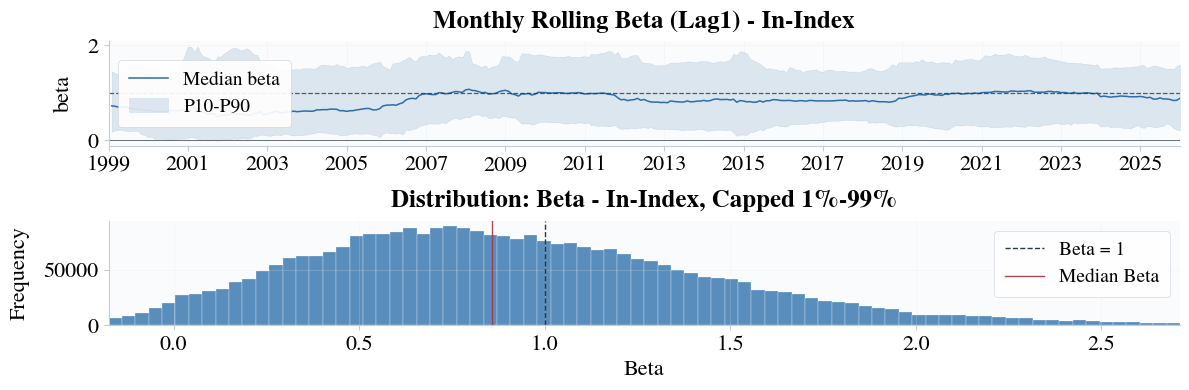

Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/Euro500_IndexReturns/monthly_rolling_beta_in_index.png


In [16]:
analysis_df = daily_company_data.copy()
analysis_df = analysis_df.sort_values(["firm_id", "date"]).reset_index(drop=True)
analysis_df["date"] = pd.to_datetime(analysis_df["date"], errors="coerce")
analysis_df["beta"] = pd.to_numeric(analysis_df["beta"], errors="coerce")
print("Daily panel beta diagnostics (in-index):")
daily_summary = pd.DataFrame([
    {
        "rows": len(analysis_df),
        "companies": analysis_df["firm_id"].nunique() if "firm_id" in analysis_df.columns else np.nan,
        "beta_non_null_share": analysis_df["beta"].notna().mean(),
        "beta_median": analysis_df["beta"].median(),
        "beta_p10": analysis_df["beta"].quantile(0.10),
        "beta_p90": analysis_df["beta"].quantile(0.90),
    }
])
display(daily_summary)
# Beta is estimated upstream on the full firm universe.
# For diagnostics here, aggregate only mapped in-index betas.
inidx_monthly = (
    analysis_df[["firm_id", "date", "beta"]]
    .dropna(subset=["firm_id", "date"])
    .assign(month_end=lambda d: d["date"].dt.to_period("M").dt.to_timestamp("M"))
    .sort_values(["firm_id", "month_end", "date"], kind="mergesort")
    .drop_duplicates(subset=["firm_id", "month_end"], keep="last")
)
print("Monthly beta diagnostics (in-index mapped):")
monthly_summary = pd.DataFrame([
    {
        "rows": len(inidx_monthly),
        "companies": inidx_monthly["firm_id"].nunique(),
        "months": inidx_monthly["month_end"].nunique(),
        "beta_non_null_share": inidx_monthly["beta"].notna().mean(),
        "beta_median": inidx_monthly["beta"].median(),
        "beta_p10": inidx_monthly["beta"].quantile(0.10),
        "beta_p90": inidx_monthly["beta"].quantile(0.90),
    }
])
display(monthly_summary)
by_month = (
    inidx_monthly.groupby("month_end", as_index=False)
    .agg(
        beta_med=("beta", "median"),
        beta_p10=("beta", lambda s: s.quantile(0.10)),
        beta_p90=("beta", lambda s: s.quantile(0.90)),
    )
    .sort_values("month_end")
)
# Distribution cap to avoid extreme tails dominating the histogram.
BETA_DIST_CAP_Q_LOW = 0.01
BETA_DIST_CAP_Q_HIGH = 0.99
beta_dist = pd.to_numeric(analysis_df["beta"], errors="coerce").dropna()
if len(beta_dist):
    q_low = float(beta_dist.quantile(BETA_DIST_CAP_Q_LOW))
    q_high = float(beta_dist.quantile(BETA_DIST_CAP_Q_HIGH))
    beta_dist_plot = beta_dist[(beta_dist >= q_low) & (beta_dist <= q_high)]
else:
    q_low, q_high = np.nan, np.nan
    beta_dist_plot = beta_dist
beta_dist_median = beta_dist_plot.median() if len(beta_dist_plot) else np.nan
fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=False)
# Panel 1: Monthly rolling beta (in-index)
axes[0].plot(by_month["month_end"], by_month["beta_med"], color=COLORS["blue"], lw=1.1, label="Median beta")
axes[0].fill_between(by_month["month_end"], by_month["beta_p10"], by_month["beta_p90"], color=COLORS["blue"], alpha=0.15, label="P10-P90")
axes[0].axhline(1.0, color=COLORS["reference"], lw=0.9, ls="--", alpha=0.8)
axes[0].axhline(0.0, color=COLORS["reference"], lw=0.7, alpha=0.7)
axes[0].set_title("Monthly Rolling Beta (Lag1) - In-Index")
axes[0].set_ylabel("beta")
style_axes(axes[0], grid_axis="both")
style_legend(axes[0], loc="best", frameon=True)
X_MIN_STEP6B = pd.Timestamp("1999-01-01")
X_MAX_STEP6B = pd.Timestamp("2025-12-31")
X_TICKS_STEP6B = pd.date_range("2000-01-01", "2026-01-01", freq="2YS")
style_time_axis(axes[0], x_min=X_MIN_STEP6B, x_max=X_MAX_STEP6B, x_ticks=X_TICKS_STEP6B, date_fmt="%Y")
# Panel 2: Beta distribution (capped)
axes[1].hist(
    beta_dist_plot,
    bins=80,
    color=COLORS["blue"],
    alpha=0.78,
    edgecolor=COLORS["white"],
    linewidth=0.25,
)
axes[1].axvline(1.0, color=COLORS["reference"], lw=1.0, ls="--", label="Beta = 1")
if pd.notna(beta_dist_median):
    axes[1].axvline(beta_dist_median, color=COLORS["red"], lw=1.0, alpha=0.9, label="Median Beta")
if pd.notna(q_low) and pd.notna(q_high):
    axes[1].set_xlim(q_low, q_high)
axes[1].set_title("Distribution: Beta - In-Index, Capped 1%-99%")
axes[1].set_xlabel("Beta")
axes[1].set_ylabel("Frequency")
style_axes(axes[1], grid_axis="both", grid_alpha=0.22)
style_legend(axes[1], loc="upper right", frameon=False)
NB_GRAPH_DIR = GRAPH_DIR / "Euro500_IndexReturns"
NB_GRAPH_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR_STEP6B = NB_GRAPH_DIR
out_path = TABLES_DIR_STEP6B / "monthly_rolling_beta_in_index.png"
plt.tight_layout()
save_figure(plt.gcf(), out_path, dpi=300)
plt.show()
print(f"Saved: {out_path}")

In [17]:
# Distribution plot moved into the combined monthly-rolling PNG in the previous cell.
# Keep this cell as a no-op placeholder for notebook structure stability.
print("Distribution plot is included in monthly_rolling_beta_in_index.png")


Distribution plot is included in monthly_rolling_beta_in_index.png


## 6. Abnormal Returns (Daily)

**Ziel**
- Berechnung firmenspezifischer abnormal returns relativ zur täglichen Marktserie.

**Formel**
$$
abnormal\_return_{i,t}=ret_{i,t}-market\_ret\_cap80_t
$$

**Input**
- `Project_Data/intermediate/daily_returns_company_all.parquet`
- `Project_Data/intermediate/euro500_daily_returns.parquet`

**Output (bearbeitet)**
- `Project_Data/intermediate/daily_returns_company_all.parquet` (inkl. `abnormal_return`)
- `Project_Data/intermediate/euro500_daily_returns.parquet` (inkl. `abnormal_return`)


In [18]:
# ---------- 6) abnormal returns on daily company panels ----------
# Two variants:
# - abnormal_return:      simple market-adjusted (ret - market_ret_cap80)
# - capm_abnormal_return: CAPM alpha (ret - rf_daily - beta*(market_ret_cap80 - rf_daily))
#   Requires beta (lag-1 monthly, from Step 5) and rf_daily (from Step 2.5).

# --- build date-level rf_daily lookup from market_daily_out ---
_rf_lookup = None
if "market_daily_out" in locals() and isinstance(market_daily_out, pd.DataFrame):
    _mdo = market_daily_out
elif "market_daily" in locals() and isinstance(market_daily, pd.DataFrame):
    _mdo = market_daily
else:
    _mdo = None
if _mdo is not None and "rf_daily" in _mdo.columns and _mdo["rf_daily"].notna().any():
    _rf_lookup = (
        _mdo[["date", "rf_daily"]]
        .assign(date=lambda d: pd.to_datetime(d["date"], errors="coerce").dt.normalize())
        .dropna(subset=["date", "rf_daily"])
        .drop_duplicates("date", keep="last")
    )

def _add_abnormal(df, rf_lookup):
    """Add abnormal_return and capm_abnormal_return columns in-place."""
    df["ret"] = pd.to_numeric(df.get("ret"), errors="coerce")
    df["market_ret_cap80"] = pd.to_numeric(df.get("market_ret_cap80"), errors="coerce")
    # Variant 1: simple market-adjusted excess return
    df["abnormal_return"] = df["ret"] - df["market_ret_cap80"]
    # Variant 2: CAPM alpha = ret - rf - beta*(rm - rf)
    if rf_lookup is not None:
        df = df.drop(columns=["rf_daily"], errors="ignore")
        df = df.merge(rf_lookup, on="date", how="left", validate="m:1")
    if "rf_daily" not in df.columns:
        df["rf_daily"] = np.nan
    rf = pd.to_numeric(df.get("rf_daily"), errors="coerce")
    beta = pd.to_numeric(df.get("beta"), errors="coerce")
    rm = df["market_ret_cap80"]
    df["capm_abnormal_return"] = np.where(
        rf.notna() & beta.notna(),
        df["ret"] - rf - beta * (rm - rf),
        np.nan,
    )
    return df

# Full panel (daily_returns_company_all.parquet)
if "returns_all_out" in locals() and isinstance(returns_all_out, pd.DataFrame):
    full_df = returns_all_out.copy()
else:
    full_df = pd.read_parquet(RETURNS_ALL_PATH).copy()

full_df = _add_abnormal(full_df, _rf_lookup)
full_df.to_parquet(RETURNS_ALL_PATH, index=False)
returns_all_out = full_df.copy()

# In-index panel (euro500_daily_returns.parquet)
if "daily_company_data" in locals() and isinstance(daily_company_data, pd.DataFrame):
    in_idx_df = daily_company_data.copy()
else:
    in_idx_df = pd.read_parquet(OUTPUT_DAILY_RETURNS_EURO500).copy()

in_idx_df = _add_abnormal(in_idx_df, _rf_lookup)
in_idx_df.to_parquet(OUTPUT_DAILY_RETURNS_EURO500, index=False)
daily_company_data = in_idx_df.copy()
returns_in_index = in_idx_df.copy()

abn_full_share = float(full_df["abnormal_return"].notna().mean()) if len(full_df) else np.nan
abn_in_share = float(in_idx_df["abnormal_return"].notna().mean()) if len(in_idx_df) else np.nan
capm_full_share = float(full_df["capm_abnormal_return"].notna().mean()) if len(full_df) else np.nan
capm_in_share = float(in_idx_df["capm_abnormal_return"].notna().mean()) if len(in_idx_df) else np.nan

print("Abnormal Return Summary")
print(f"- formula: abnormal_return      = ret - market_ret_cap80")
print(f"- formula: capm_abnormal_return = ret - rf_daily - beta*(market_ret_cap80 - rf_daily)")
print("  (capm variant requires beta from Step 5 and rf_daily from Step 2.5; NaN if either missing)")
print(f"- full panel   abnormal_return      non-null: {abn_full_share*100:.2f}%" if pd.notna(abn_full_share) else "- full panel   abnormal_return      non-null: n/a")
print(f"- in-index     abnormal_return      non-null: {abn_in_share*100:.2f}%" if pd.notna(abn_in_share) else "- in-index     abnormal_return      non-null: n/a")
print(f"- full panel   capm_abnormal_return non-null: {capm_full_share*100:.2f}%" if pd.notna(capm_full_share) else "- full panel   capm_abnormal_return non-null: n/a")
print(f"- in-index     capm_abnormal_return non-null: {capm_in_share*100:.2f}%" if pd.notna(capm_in_share) else "- in-index     capm_abnormal_return non-null: n/a")

Abnormal Return Summary
- formula: abnormal_return      = ret - market_ret_cap80
- formula: capm_abnormal_return = ret - rf_daily - beta*(market_ret_cap80 - rf_daily)
  (capm variant requires beta from Step 5 and rf_daily from Step 2.5; NaN if either missing)
- full panel   abnormal_return      non-null: 98.01%
- in-index     abnormal_return      non-null: 99.36%
- full panel   capm_abnormal_return non-null: 91.18%
- in-index     capm_abnormal_return non-null: 92.92%


## 7. Market Capitalisation (from NP5 Cache)

Map quarterly market cap (`TR.CompanyMarketCap`) already pulled by `LSEG_DataPull_Netpayout.ipynb`
onto the daily returns panel via `merge_asof` (backward fill, max 365-day tolerance).

The NP4 cache (`np4_step_rows.parquet`) is shared — no new LSEG pull required if the Netpayout
notebook has already run. Adds `mcap_eur` and `log_mcap` to both daily returns parquets.

In [19]:
# ── 7. Market Capitalisation — load from NP5 cache, map to daily panels ──────

NP5_STEP_ROWS = CACHE_DATA_DIR / 'np5_step_rows.parquet'

if not NP5_STEP_ROWS.exists():
    raise FileNotFoundError(
        f'NP5 cache not found: {NP5_STEP_ROWS}\n'
        'Run LSEG_DataPull_Netpayout.ipynb first to populate the cache.'
    )

# Load and clean quarterly market cap
mcap_raw = pd.read_parquet(NP5_STEP_ROWS)
mcap = (
    mcap_raw[['firm_id', 'date', 'mcap_eur']]
    .copy()
    .assign(
        date=lambda d: pd.to_datetime(d['date'], errors='coerce').dt.normalize(),
        mcap_eur=lambda d: pd.to_numeric(d['mcap_eur'], errors='coerce'),
    )
    .dropna(subset=['firm_id', 'date', 'mcap_eur'])
    .query('mcap_eur > 0')
    .sort_values(['firm_id', 'date'])
    .drop_duplicates(['firm_id', 'date'], keep='last')
    .reset_index(drop=True)
)

print(f'NP4 market cap loaded: {len(mcap):,} rows, '
      f'{mcap["firm_id"].nunique():,} firms, '
      f'{mcap["date"].min().date()} – {mcap["date"].max().date()}')
print(f'mcap_eur  median={mcap["mcap_eur"].median()/1e9:.2f}B  '
      f'p5={mcap["mcap_eur"].quantile(.05)/1e9:.2f}B  '
      f'p95={mcap["mcap_eur"].quantile(.95)/1e9:.2f}B')


def _merge_mcap_to_daily(daily_df: pd.DataFrame, mcap_df: pd.DataFrame) -> pd.DataFrame:
    """
    Backward-fill quarterly mcap onto a daily panel via merge_asof.
    Tolerance: 365 days (annual NP5 points can cover the full year between observations).
    """
    df = daily_df.drop(columns=['mcap_eur'], errors='ignore').copy()
    df['date'] = pd.to_datetime(df['date'], errors='coerce').dt.normalize()

    chunks = []
    for firm, grp in df.groupby('firm_id', sort=False):
        m = mcap_df[mcap_df['firm_id'] == firm][['date', 'mcap_eur']].sort_values('date')
        if m.empty:
            grp = grp.copy()
            grp['mcap_eur'] = np.nan
        else:
            grp = pd.merge_asof(
                grp.sort_values('date'),
                m,
                on='date',
                direction='backward',
                tolerance=pd.Timedelta('365D'),
            )
        chunks.append(grp)

    return pd.concat(chunks, ignore_index=True).sort_values(['firm_id', 'date']).reset_index(drop=True)


# ── Apply to in-index panel ───────────────────────────────────────────────────
if 'daily_company_data' in locals() and isinstance(daily_company_data, pd.DataFrame):
    in_idx_df = daily_company_data.copy()
else:
    in_idx_df = pd.read_parquet(OUTPUT_DAILY_RETURNS_EURO500).copy()

in_idx_df = _merge_mcap_to_daily(in_idx_df, mcap)
in_idx_df.to_parquet(OUTPUT_DAILY_RETURNS_EURO500, index=False)
daily_company_data = in_idx_df.copy()
returns_in_index   = in_idx_df.copy()

cov_in = in_idx_df['mcap_eur'].notna().mean()
print(f'\nIn-index panel  — mcap_eur coverage: {cov_in:.1%}  ({in_idx_df["mcap_eur"].notna().sum():,} / {len(in_idx_df):,} rows)')

# ── Apply to full panel ───────────────────────────────────────────────────────
if 'returns_all_out' in locals() and isinstance(returns_all_out, pd.DataFrame):
    full_df = returns_all_out.copy()
else:
    full_df = pd.read_parquet(RETURNS_ALL_PATH).copy()

full_df = _merge_mcap_to_daily(full_df, mcap)
full_df.to_parquet(RETURNS_ALL_PATH, index=False)
returns_all_out = full_df.copy()

cov_all = full_df['mcap_eur'].notna().mean()
print(f'Full panel      — mcap_eur coverage: {cov_all:.1%}  ({full_df["mcap_eur"].notna().sum():,} / {len(full_df):,} rows)')
print('\nSaved: euro500_daily_returns.parquet + daily_returns_company_all.parquet (with mcap_eur)')

NP4 market cap loaded: 360,087 rows, 1,246 firms, 1995-12-31 – 2025-12-31
mcap_eur  median=0.43B  p5=0.01B  p95=22.24B

In-index panel  — mcap_eur coverage: 100.0%  (3,457,221 / 3,458,495 rows)
Full panel      — mcap_eur coverage: 99.6%  (3,978,758 / 3,993,295 rows)

Saved: euro500_daily_returns.parquet + daily_returns_company_all.parquet (with mcap_eur)
